# Installation and configuration of IBL packages

In [78]:
!pip install --quiet ONE-api
!pip install --quiet ibllib

In [79]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [80]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

# Finding subjects with training data

In [81]:
import numpy as np

# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTrials.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

# Loading trials data for a single subject

In [82]:
# Load in the subjectTrials table and sessionTrials table for the first subject
subject = subjects[0]
subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')
session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

# Add in lab, task_protocol, subject name information from the sessions table
if 'task_protocol' in subject_trials:
    subject_trials = subject_trials.drop('task_protocol', axis=1)
subject_trials = subject_trials.set_index('session').join(session_trials.drop('date', axis=1))

/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


The `subject_trials` table contains all the trials data for each training session collected in the subject. See [here](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.ls81qq9ihg4x) for more information about this dataset.

We can find the number of sessions collected, or the number of times the subject was run under a specific task protocol

In [83]:
# Find the number of sessions for this subject
n_sessions = subject_trials.index.unique().size
print(f'Subject {subject} has {n_sessions} sessions')

# Find the number of times a task protocol was run
n_protocols = subject_trials[~subject_trials.index.duplicated()].task_protocol.value_counts()
print(n_protocols)

Subject CSHL045 has 76 sessions
task_protocol
_iblrig_tasks_biasedChoiceWorld6.3.1      17
_iblrig_tasks_trainingChoiceWorld6.1.3    14
_iblrig_tasks_trainingChoiceWorld6.2.5    12
_iblrig_tasks_trainingChoiceWorld6.3.1    11
_iblrig_tasks_biasedChoiceWorld6.2.5       6
_iblrig_tasks_trainingChoiceWorld6.0.6     3
_iblrig_tasks_trainingChoiceWorld6.2.4     3
_iblrig_tasks_ephysChoiceWorld6.2.5        3
_iblrig_tasks_trainingChoiceWorld6.2.1     2
_iblrig_tasks_ephysChoiceWorld6.4.0        2
_iblrig_tasks_trainingChoiceWorld6.1.1     1
_iblrig_tasks_trainingChoiceWorld6.1.2     1
_iblrig_tasks_trainingChoiceWorld6.2.0     1
Name: count, dtype: int64


We can get the trials data for an individual session of choice, here a the first session using the biasedChoiceWorld protocol

In [84]:
# Get the trials data for a single session
# Find a session run under biasedChoiceWorld
sess = subject_trials[subject_trials['task_protocol'].str.contains('biasedChoiceWorld')].index.unique()[0]
trials = subject_trials[subject_trials.index == sess]

Using this data we can plot the psychometric curve and compute some performance metrics, for example the number of trials in the session or the performance of the mouse on easy trials (50% and 100% contrast)

Number of trials for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 682
Performance easy for session a4f7079b-d157-4de9-ba80-de9a98f35c8b: 0.9457364341085271


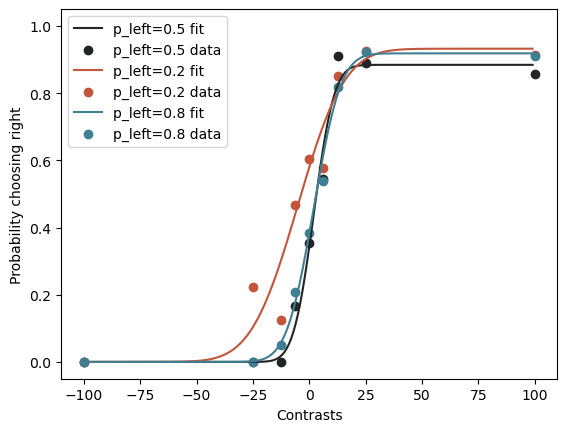

In [85]:
from brainbox.behavior.training import plot_psychometric, compute_n_trials, compute_performance_easy, compute_performance

plot_psychometric(trials)
n_trials = compute_n_trials(trials)
perf_easy = compute_performance_easy(trials)
print(f'Number of trials for session {sess}: {n_trials}')
print(f'Performance easy for session {sess}: {perf_easy}')

## Combining training criteria

Another [dataset](https://docs.google.com/document/d/1OqIqqakPakHXRAwceYLwFY9gOrm8_P62XIfCTnHwstg/edit#heading=h.18vu2zskyq0r) is available that contains information about the session at which the subject reached certain training criteria in the IBL training pipeline. More information can be found about the training pipeline in the study [A standardized and reproducible method to measure decision-making in mice](https://doi.org/10.1101/2020.01.17.909838).

We can download this dataset in the following way

In [86]:
subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

We can combine this with our subject trials table to see how the subject progressed

In [87]:
subject_trials = (subject_trials
          .join(subject_training.set_index('session'))
          .sort_values(by=['session_start_time', 'intervals_0']))
subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

Our subject trials table now has a new column that indicates the training criteria of the mouse at each session. We can use this information to make a plot of how the performance of the mouse improved across training days.

We will need to compute the performance per session and add this column to our dataframe and also add in a column for training day.

In [88]:
sessions = subject_trials.index.unique()
for n_sess, sess in enumerate(sessions):
  trials = subject_trials[subject_trials.index == sess]
  perf_easy = compute_performance_easy(trials)
  subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
  subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess

Note since we already ordered by session_start_time above our table was already sorted. Here we have simply assigned each training session to a training day but there are some cases where multiple training sessions were run on the same day so this may be something you want to account for in your analysis.

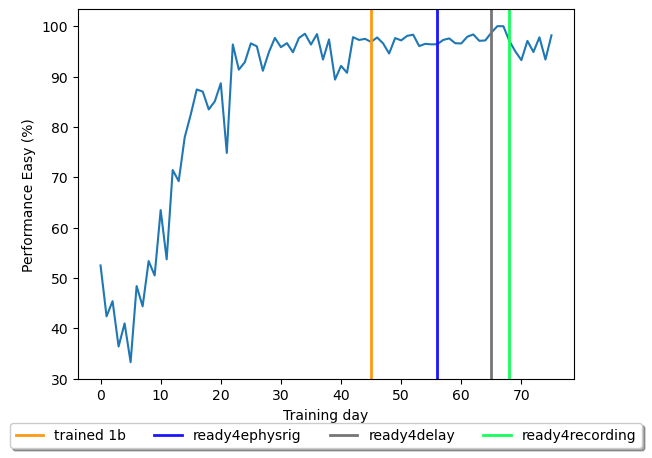

In [89]:
import matplotlib.pyplot as plt
from ibllib.pipes.training_status import TRAINING_STATUS
fig, ax = plt.subplots(1, 1)
ax.plot(subject_trials['training_day'], subject_trials['performance_easy'] * 100)
ax.set_xlabel("Training day")
ax.set_ylabel("Performance Easy (%)")
status = subject_trials.drop_duplicates(subset='training_status', keep='first')
for _, st in status.iterrows():
    if st['training_status'] in ['untrainable', 'unbiasable']:
        continue
    if TRAINING_STATUS[st['training_status']][0] <= 0:
        continue
    ax.axvline(st['training_day'], linewidth=2,
               color=np.array(TRAINING_STATUS[st['training_status']][1]) / 255, label=st['training_status'])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
                   fancybox=True, shadow=True, ncol=5)

# Combining data across multiple subjects

We can loop over all the subjects available to get a large dataframe that contains the data for all the subjects. Here is an example of how this can be done


In [90]:
import pandas as pd

all_trials = []

# Download two tables, subject trials table and subject training table and combine
for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra columns for performance easy and training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    perf_easy = compute_performance_easy(trials)
    subject_trials.loc[subject_trials.index == sess, 'performance_easy'] = perf_easy
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

0/140


/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL045/#2024-04-10#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL046/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL047/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/churchlandlab/CSHL049/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default

50/140


/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/angelakilab/IBL-T3/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/mrsicflogellab/IBL_001/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(
/usr/local/anaconda3/lib/python3.11/site-packages/one/util.py:442: ALFWarning: No default revision for dataset aggregates/Subjects/mrsicflogellab/IBL_002/#2024-08-21#/_ibl_subjectTrials.table.pqt; using most recent
  warnings.warn(


100/140


Once we have this large training table aggregated across all subjects we can manipulate this table to view different properties. For example we can see how the pyshcometric curves varies across the different training stages across all subjects

<Axes: xlabel='signed_contrast', ylabel='choice'>

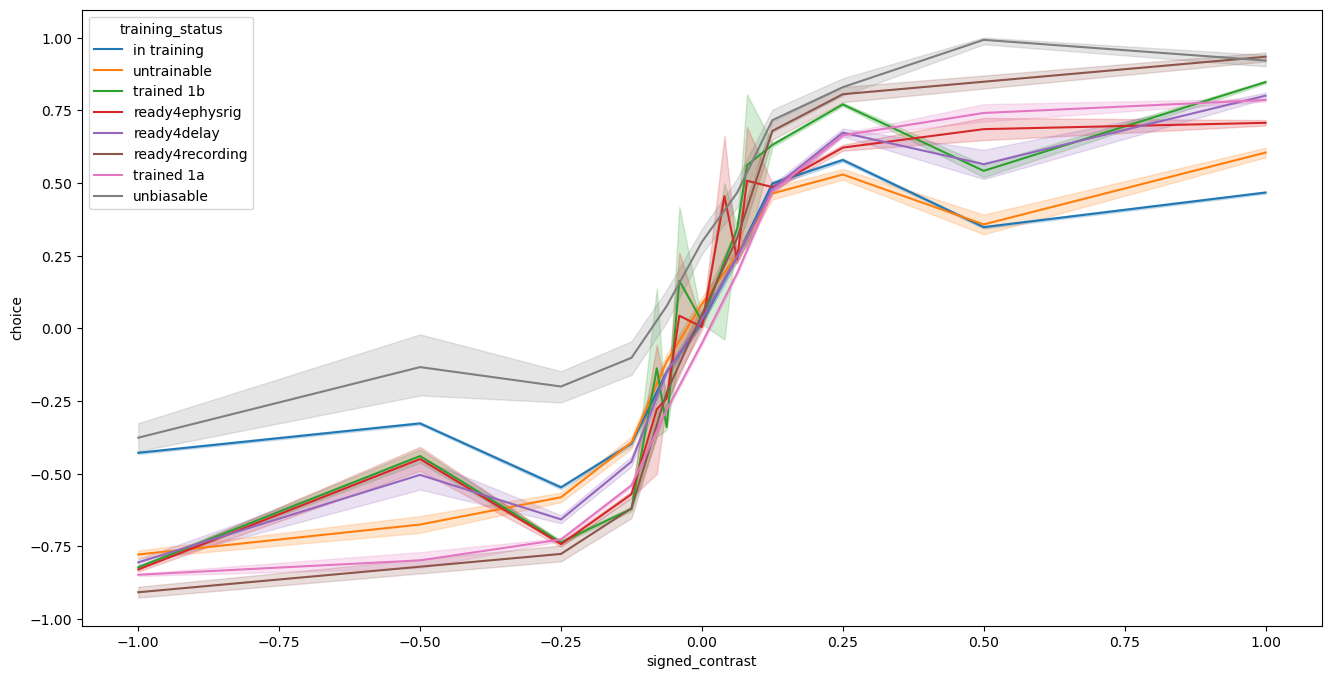

In [91]:
import seaborn as sns
# plot psychometric curves for the whole dataframe
all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

Or we can look how the performance on easy trial progresses over training days across labs

/usr/local/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


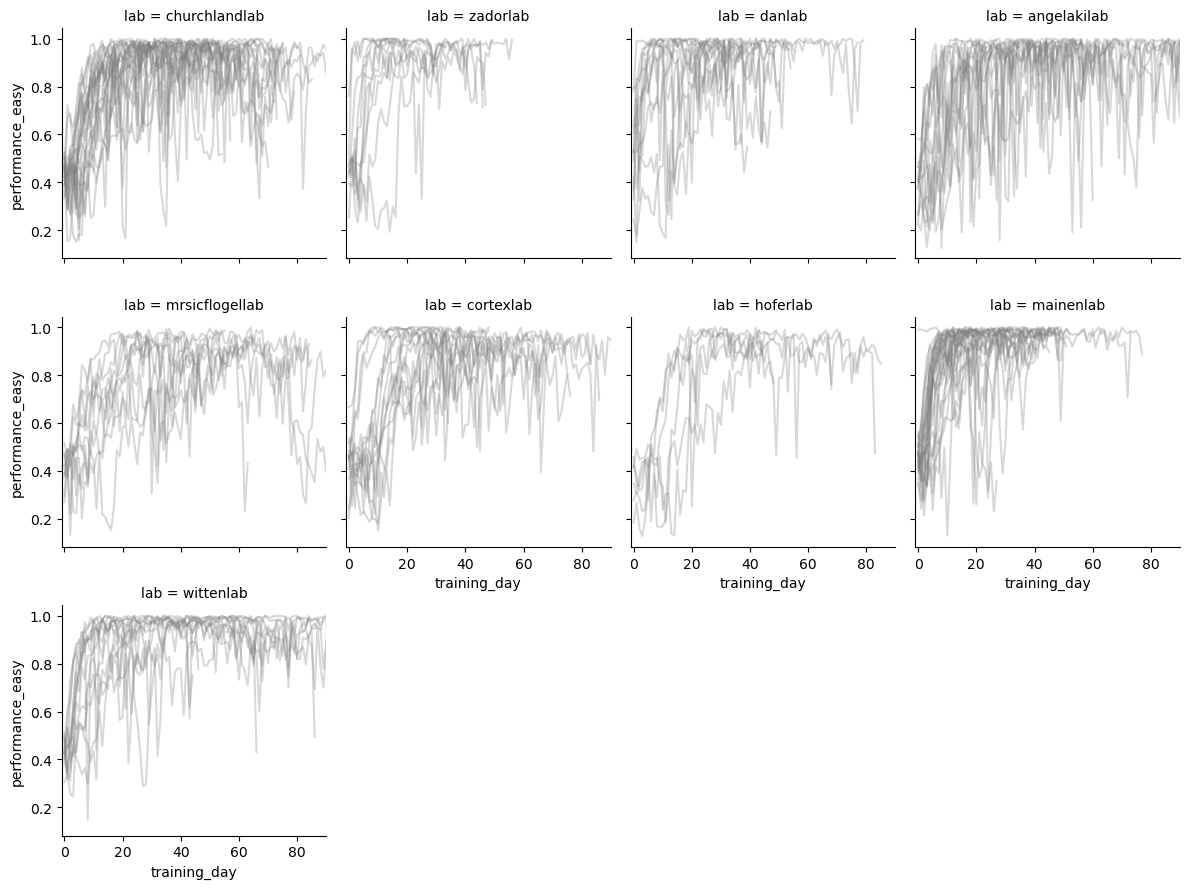

In [92]:
# Remove duplicate rows that we don't need for the plots
fig = sns.FacetGrid(all_trials.drop_duplicates('session'),
                    col="lab", col_wrap=4,
                    sharex=True, sharey=True, aspect=1, hue="subject", xlim=[-1, 90])
fig.map(sns.lineplot, "training_day",
        "performance_easy", color='gray', alpha=0.3)

# Additional resources

Documentation

- [ONE documentation](https://int-brain-lab.github.io/iblenv/notebooks_external/one_quickstart.html#)
- [Getting started with ONE](https://colab.research.google.com/drive/1y3sRI1wC7qbWqN6skvulzPOp6xw8tLm7)
- [Loading trials data](https://int-brain-lab.github.io/iblenv/notebooks_external/loading_trials_data.html)


Where can I find help?
- Issues with the data? Post an issue here: https://neurostars.org/ with the tag `ibl`
- Alternatively post an issue here: https://github.com/int-brain-lab/iblenv/issues
- General questions about the datasets or publications? Email: info@internationalbrainlab.org




> *All data are made available under the CC BY 4.0 license.*

## Data preprocessing fot Q1
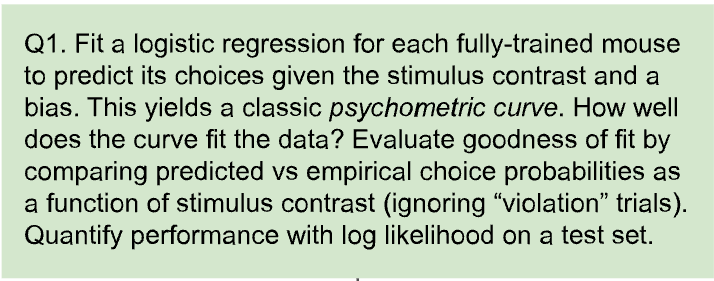


`all_trials` already contains trial data from all mice and all sessions.

For Q1, we need these columns:

- `subject` - mouse ID
- `session` - session ID
- `training_status` - training status
- `contrastLeft` - left stimulus contrast
- `contrastRight` - right stimulus contrast
- `choice` - mouse choice (`-1`, `1`, or violation)
- `signed_contrast` - stimulus contrast already created from `contrastLeft` and `contrastRight`

most of column already exists in `all_trials`, the next preprocessing steps are:

1. Keep only fully-trained sessions.
2. Remove violation trials.
3. Convert `choice` into `choice_binary` for logistic regression.

In [93]:

print(all_trials.columns)

Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast'],
      dtype='object')


#### Data preprocessing steps

##### 1. We create a copy of `all_trials` and call it `df_q1`. 

In [94]:
df_all = all_trials.copy()

##### 2. we need only fully-trained sessions 

For this, we use the column `training_status`.

Fully-trained statuses are:

- `ready4ephysrig`
- `ready4delay`
- `ready4recording`

filter:
- mouse/session is fully trained
- choice is valid: `-1` or `1`
- `signed_contrast` is not missing

In [95]:
FULLY_TRAINED_STATUSES = [
    'ready4ephysrig',
    'ready4delay',
    'ready4recording'
]

is_fully_trained = df_all['training_status'].isin(FULLY_TRAINED_STATUSES)
is_valid_choice = df_all['choice'].isin([-1, 1])    
has_signed_contrast = df_all['signed_contrast'].notna()

df_q1 = df_all.loc[
    is_fully_trained & is_valid_choice & has_signed_contrast
].copy()



##### 3. create binary choice column

Logistic regression usually need the output variable to be binary: `0` or `1`.

The original `choice` column has values `-1` and `1`.

So we create `choice_binary` column:

- `choice = 1` becomes `choice_binary = 1`
- `choice = -1` becomes `choice_binary = 0`

This column will be the target variable for logistic regression.

In [96]:
# Create binary choice for logistic regression
# choice = 1  -> choice_binary = 1
# choice = -1 -> choice_binary = 0

df_q1['choice_binary'] = 0
df_q1.loc[df_q1['choice'] == 1, 'choice_binary'] = 1 #For rows where choice is 1, set choice_binary to 1.


df_q1[['choice', 'choice_binary']].head()

,choice,choice_binary
41824,1.0,1
41825,1.0,1
41826,1.0,1
41827,1.0,1
41828,-1.0,0


##### 4. select input and target columns

For logistic regression, we need:

- `X` - input feature
- `y` - target we want to predict

In this task:

- `X = signed_contrast`
- `y = choice_binary`

The model will learn how stimulus contrast predicts the mouse choice.

In [97]:
X = df_q1[['signed_contrast']]
y = df_q1['choice_binary']

print(X.head())
print("----------------------")
print(y.head())

       signed_contrast
41824          -0.1250
41825           0.0625
41826          -0.1250
41827          -0.0000
41828          -0.0000
----------------------
41824    1
41825    1
41826    1
41827    1
41828    0
Name: choice_binary, dtype: int64


##### 5. Split trials for each mouse

We do not split mice into 80% and 20%.

Instead, for each mouse separately, we split that mouse's trials:

- 80% of trials are used for training
- 20% of trials are used for testing

This is needed because each mouse gets its own logistic regression model.
The test trials are used later to calculate log likelihood.


The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast

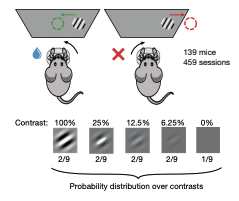

##### 6. Fit logistic regression for each mouse

After splitting the trials, we train the model using only the training data.

The model uses:

- `signed_contrast` as input
- `choice_binary` as target

The model learns two parameters:

- `bias` — intercept
- `contrast_weight` — effect of stimulus contrast



вероятность того, что модель предсказывает выбор, закодированный как 1.

P(choice_binary = 1) = sigmoid(bias + contrast_weight * signed_contrast)

Для каждой мыши отдельно обучили Logistic Regression, чтобы предсказывать choice_binary по signed_contrast.

In [98]:
print(df_q1.columns)

display(df_q1[['subject', 'session','choice','contrastLeft','contrastRight']].head(5))


Index(['session', 'intervals_0', 'intervals_1', 'goCue_times',
       'response_times', 'choice', 'stimOn_times', 'contrastLeft',
       'contrastRight', 'feedback_times', 'feedbackType', 'rewardVolume',
       'probabilityLeft', 'firstMovement_times', 'goCueTrigger_times',
       'stimOnTrigger_times', 'stimOffTrigger_times',
       'stimFreezeTrigger_times', 'stimOff_times', 'stimFreeze_times', 'phase',
       'position', 'quiescence', 'protocol_number', 'session_start_time',
       'training_status', 'lab', 'subject', 'number', 'task_protocol',
       'projects', 'performance_easy', 'training_day', 'session_number',
       'signed_contrast', 'choice_binary'],
      dtype='object')


,subject,session,choice,contrastLeft,contrastRight
41824,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,0.0625,NaN
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.125
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,1.0,NaN,0.000
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-1.0,NaN,0.000


Здесь df_q1 делится на группы по мышам.
Каждая группа = все trials одной мыши.

In [99]:
for subject, mouse_data in df_q1.groupby('subject'):
    print("Subject:", subject)
    print(mouse_data.shape)
    display(mouse_data.head(2))
    break

Subject: CSHL045
(17953, 36)


,session,intervals_0,intervals_1,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,feedback_times,...,lab,subject,number,task_protocol,projects,performance_easy,training_day,session_number,signed_contrast,choice_binary
41824,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0000,10.361503,7.1431,7.7614,1.0,NaN,NaN,0.125,7.7923,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,-0.1250,1
41825,85501aad-64e6-4137-a44e-2c933c9eec5f,10.8138,15.470302,11.3389,13.8841,1.0,11.3105,0.0625,NaN,13.8842,...,churchlandlab,CSHL045,2,_iblrig_tasks_biasedChoiceWorld6.3.1,ibl_neuropixel_brainwide_01,0.964072,56.0,NaN,0.0625,1


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

mouse_models = {}


for subject, mouse_data in df_q1.groupby('subject'):
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0, #you get the same split every time. это не количество.Это просто номер фиксированного варианта случайности.
        stratify=y
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    mouse_models[subject] = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],

    }


##### 7. Predict choice probabilities on the test set using LogisticRegression 20% test data

По сути мы берем уже обученную модель и прогоняем через нее test data, то есть данные, на которых модель не обучалась.


After training the logistic regression model on the training trials, we apply the trained model to the test trials.

The test trials were not used during fitting, so they act as unseen data.

We use `predict_proba - это готовая функция внутри sklearn модели LogisticRegression`, because the task asks for choice probabilities, not only final class labels.

For each test trial, the model predicts:

`P(choice_binary = 1)`

This is the model's predicted probability that the mouse makes the choice coded as `1`.

These predicted probabilities are later compared with the empirical choice probabilities from the same test set.

In [101]:
for subject, result in mouse_models.items():
    model = result['model']
    X_test = result['X_test']

    class_1_index = list(model.classes_).index(1) #найди, в какой колонке predict_proba находится вероятность класса 1.

    p_test_predicted = model.predict_proba(X_test)
    p_test_predicted = p_test_predicted[:, class_1_index] #[:, 1] значит: взять все строки и вторую колонку.

    mouse_models[subject]['p_test_predicted'] = p_test_predicted

##### 8. Calculate empirical probability on the 20% test data without Logistic regression 

$$
\hat{P}_{\text{test}}(\text{choice}=1 \mid \text{signed contrast}=c)
=

\frac{\text{Number of test trials where choice}=1\text{ at contrast }c}
{\text{Total number of test trials at contrast }c}
$$


Here, 

X is `signed_contrast` 

Y is `choice_binary`




In [102]:
for subject, result in mouse_models.items():
    test_data = result['X_test'].copy()
    test_data['choice_binary'] = result['y_test']

    p_test_empirical = (test_data
                                .assign(choice_is_1 = test_data['choice_binary'] == 1)
                                .groupby('signed_contrast')['choice_is_1']
                                .mean()
                          )

    mouse_models[subject]['p_test_empirical'] = p_test_empirical

##### 9. calculate log likelihood on the test set Logistic Regression (Log Loss)

We use the test trials to measure how well the model predicts unseen data.

`log_loss` gives negative log likelihood.

So we multiply it by `-1` to get log likelihood.

A better model has log likelihood closer to `0`.

A model near chance is around `log(0.5) = -0.693`.

In [103]:
from sklearn.metrics import log_loss

for subject, result in mouse_models.items():

    y_test = result['y_test']
    
    p_test_predicted = result['p_test_predicted']

    log_likelihood = -log_loss(y_test, p_test_predicted)

    mouse_models[subject]['log_likelihood'] = log_likelihood

##### 10. Результат

After fitting the model for each mouse, we save the important results in one table.

For each mouse, we save:

- `subject` - mouse ID
- `bias` - model intercept  - here logictic regression calculate automitically 
- `contrast_weight` - effect of stimulus contrast
- `log_likelihood` - log loss fuction

This table helps compare model performance across mice.

In [104]:
#lets summarize the results

results = []

for subject, result in mouse_models.items():
    model = result['model']

    results.append({
        'subject': subject,
        'bias': model.intercept_[0],
        'contrast_weight': model.coef_[0][0],
        'log_likelihood': result['log_likelihood']
    })

results_df = pd.DataFrame(results)

results_df.head()

,subject,bias,contrast_weight,log_likelihood
0,CSHL045,-0.029792,7.671385,-0.449487
1,CSHL046,-0.060998,5.092882,-0.511274
2,CSHL047,-1.124388,5.097826,-0.427543
3,CSHL049,0.461201,7.375145,-0.459950
4,CSHL051,-0.584094,3.514391,-0.535279


### Интерпретация `log_likelihood`

|  `log_likelihood` | Интерпретация |
|---:|---|
| `0` to `-0.3` | Very good / очень хорошая модель |
| `-0.3` to `-0.5` | Good / хорошая модель |
| `-0.5` to `-0.65` | Okay / moderate / средняя модель |
| Around `-0.693` | Chance level / уровень случайного угадывания |
| Less than `-0.693` | Bad / хуже случайного угадывания |

##### 11. here we visually evaluate the Empirical probability vs Predicted probability (Logistic regression) 

We already evaluated the model numerically using the log-likelihood in Step 10. 
Here, we evaluate the model visually:

- Empirical probability represents the mouse’s actual choices in the test data.

- Predicted probability represents the probabilities estimated by the logistic regression model.

If the predicted curve is close to the empirical data points, the psychometric curve fits the test data well.


In [105]:
#This selects one mouse from the results_df table by taking the row at index 6.(just example of mouse #6) 
subject = results_df['subject'].iloc[23] #Это выбирает одну мышь из таблицы results_df берет элемент с индексом 6.

#Gets the empirical probabilities for the selected mouse.
p_test_empirical = mouse_models[subject]['p_test_empirical'] #реальные probabilities на test set по contrast.
contrast_values = p_test_empirical.index.to_frame(index=False) # just convert to DataFrame.

#Gets the trained logistic regression model for the selected mouse.
mouse6model = mouse_models[subject]['model']
class_1_index = list(mouse6model.classes_).index(1) 

p_test_predicted_curve = mouse6model.predict_proba(contrast_values)
p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

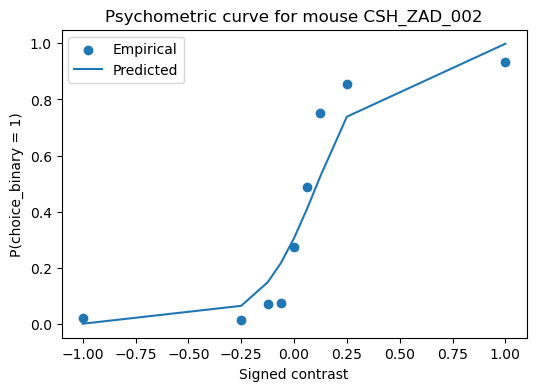

In [106]:
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

This code finds the log-likelihood for the selected mouse and prints the mouse ID and its log-likelihood value.

In [107]:
mouse_ll = results_df.loc[
    results_df['subject'] == subject,
    'log_likelihood'
].values[0]

print("Subject:", subject)
print("Log likelihood:", mouse_ll)

Subject: CSH_ZAD_002
Log likelihood: -0.4296368624958548


This code combines the empirical and predicted psychometric curves for all mice and then calculates the average curve.

In [108]:
all_curves = []       #creates an empty list to store results for every mouse.

for subject, result in mouse_models.items():
    model = result['model']

    # empirical probabilities already calculated on test set
    p_test_empirical = result['p_test_empirical']       #gets the real probability of choosing 1 for each contrast.

    # use the same signed_contrast values for predicted curve
    contrast_values = p_test_empirical.index.to_frame(index=False)   #prepares the contrast values for the model.
    class_1_index = list(model.classes_).index(1)         #keeps only the probability of choice = 1.

    p_test_predicted_curve = model.predict_proba(contrast_values)        #calculates the predicted probabilities.
    p_test_predicted_curve = p_test_predicted_curve[:, class_1_index]

    curve_df = pd.DataFrame({                           #creates one table for the current mouse.
        'subject': subject,
        'signed_contrast': p_test_empirical.index,
        'p_test_empirical': p_test_empirical.values,
        'p_test_predicted': p_test_predicted_curve
    })

    all_curves.append(curve_df)              #adds this mouse’s results to the list.

all_curves_df = pd.concat(all_curves, ignore_index=True)         #combines all mice into one DataFrame.

mean_curve = (
    all_curves_df
    .groupby('signed_contrast')                 #groups results by contrast.
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),        #calculates the average empirical probability across mice.
        mean_predicted=('p_test_predicted', 'mean')          #calculates the average predicted probability across mice.
    )
    .reset_index()
    .sort_values('signed_contrast')
)


##### Lets visualize. Plot Psychometric Curves Across All Mice

- This plot compares the observed and model-predicted probabilities.

- The empirical probability is calculated from the actual choices in the test data. 
If the red and black lines are close, the model fits the average behavior of the mice well.

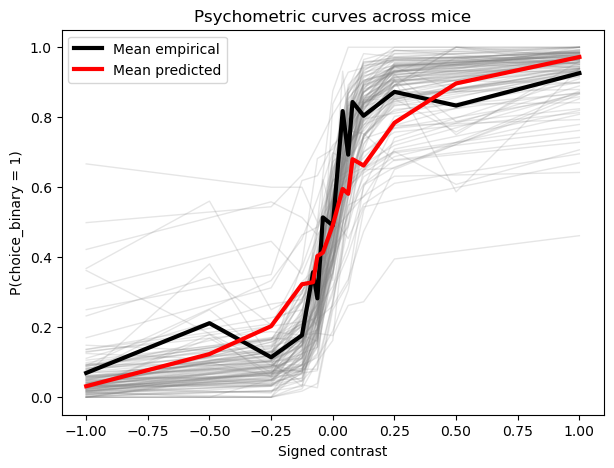

In [109]:
plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2,
        linewidth=1
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_predicted'],
    color='red',
    linewidth=3,
    label='Mean predicted'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice')
plt.legend()
plt.show()

#### Q1 interpretation


- The main result is that the probability of choice_binary = 1 increased as signed_contrast increased. 

- This shows that stimulus contrast strongly affects the mouse’s choice.

- The red predicted curve follows the black empirical curve quite well, so logistic regression captures the main relationship between contrast and choice.

- The average predicted curve was close to the average empirical curve, so the model captured the main relationship between contrast and choice.

- logistic regression provided a good basic psychometric model, but adding behavioral history variables could improve the fit.

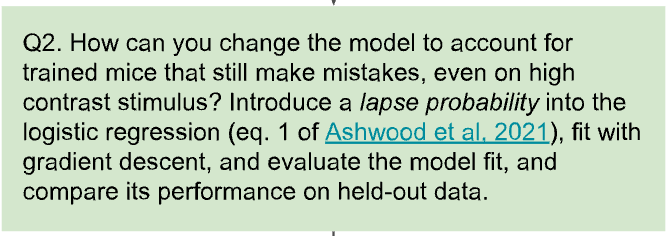

### Q2-1. From Q1 to Lapse Analysis

In Q1, logistic regression captured the main relationship between `signed_contrast` and mouse choice. As contrast increased, the probability of `choice_binary = 1` also increased.
In Q1, we used standard logistic regression to model how signed_contrast affects the mouse’s choice.

The model captured the main trend well with Logistic Regression:

$$
P(Y=1 \mid x)
=

\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

The sigmoid function is:

$$
\operatorname{sigmoid}(z)
=

\frac{1}{1+e^{-z}}
$$



### Q2-2. However, some mice still made errors at high contrast. 
##### Standard logistic regression usually predicts probabilities close to 0 or 1 at high contrast, so it may not capture these lapse errors.
Ashwood et al. suggest that lapses may not be completely random. 
Mice can switch between engaged and disengaged behavioral states, and disengaged states can continue across several trials. 

High-contrast errors:

`abs(signed_contrast) >= 0.5` and `feedbackType == -1`


### Q2-3. The mouse sometimes chooses based on the stimulus, and sometimes makes a random choice because of a lapse.

So, we build a new, extended model:

- Logistic regression describes the mouse’s choice based on signed_contrast(Q1).

- λ describes how often the mouse ignores the stimulus and chooses randomly.

- sklearn.LogisticRegression cannot estimate λ, so for the lapse model we usually write our own probability function and optimize the negative log-likelihood.


Это формула логистической регрессией с учетом + lapse_probability


$$ P =
\frac{\lambda}{2}
+
(1 - \lambda)
\cdot
\frac{1}{1 + e^{-(b + wx)}}
$$


### Q2-4. How we get prev formula?


We use 0.5 because during a lapse, 

we assume that the mouse chooses randomly between two possible choices: 0 and 1. 

Then, each choice has a probability of 50%.


The general model is:

$$
P
=

\gamma
+
(1-\gamma-\delta)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

If the lower and upper lapse rates are equal:

$$
\gamma=\delta=\frac{\lambda}{2}
$$

Substitute them into the general formula:

$$
P
=

\frac{\lambda}{2}
+
\left(1-\frac{\lambda}{2}-\frac{\lambda}{2}\right)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

then we get:

$$
P
=

\frac{\lambda}{2}
+
(1-\lambda)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

Here, 
*  γ - gamma - its errors at high negative contrast.
*  δ - delta - its errors at high positive contrast.
*  λ - lambda, the total lapse probability.



### Q2-5. Gradient descent is used to find the parameters.

   - In Q1, sklearn LogisticRegression() already did optimization for us. 

   - It learned ->  `bias + contrast_weight + internally.`
 
 - In Q2, because we add a custom lapse_probability, normal LogisticRegression() cannot fit it directly. 

 - So we write our own gradient descent to learn ->  `bias + contrast_weight + lapse_probability`

#### Gradient descent update

$$
b \leftarrow b - \alpha \frac{\partial  LogLoss}{\partial b}
$$

$$
w \leftarrow w - \alpha \frac{\partial  LogLoss}{\partial w}
$$

$$
lapse_{\text{raw}} \leftarrow lapse_{\text{raw}} - \alpha \frac{\partial  LogLoss}{\partial lapse_{\text{raw}}}
$$

where:

- $\alpha$ = learning rate

- $\lambda$ = lapse probability

- $p$ = predicted probability that `choice_binary = 1`

### Q2-6. log likelihood / log loss

The negative log likelihood is:

$$
LOG LOSS =
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i \log(p_i)
+
(1 - y_i)\log(1 - p_i)
\right]
$$

                                        
`Log Loss = - mean( y * log(p) + (1 - y) * log(1 - p) )`

where:

- `y_i` = real choice on trial \(i\), either `0` or `1`
- `p_i` = predicted probability of `choice_binary = 1`
- `N` = number of trials

A smaller `Log loss` means better model fit.

посчитать вероятность choice = 1 с учётом двух вещей:

- влияния signed_contrast через logistic regression

- случайных ошибок мыши через lapse_probability.

То есть модель описывает -> обычно мышь выбирает по stimulus, но иногда игнорирует его и выбирает случайно.

### Q2-7. Coding Part 

* Selects trials with high contrast: `|signed_contrast| >= 0.5`.

  * high contrast

  * `feedbackType == -1`
  
Using `.abs()` includes both strong left and strong right contrasts.


In [110]:
#Step 2. get high-contrast mistakes 
high_contrast_trials = df_q1[df_q1['signed_contrast'].abs() >= 0.5]
print(df_q1['signed_contrast'].min())
print(df_q1['signed_contrast'].max())
print(sorted(df_q1['signed_contrast'].dropna().unique()))


high_contrast_mistakes = df_q1[
    (df_q1['signed_contrast'].abs() >= 0.5) &
    (df_q1['feedbackType'] == -1)
]

-1.0
1.0
[-1.0, -0.5, -0.25, -0.125, -0.08, -0.0625, -0.04, -0.0, 0.04, 0.0625, 0.08, 0.125, 0.25, 0.5, 1.0]


### Q2-7.1 Implementation of a Logistic + Lapse Ftiing Model Using Gradient Descent


In [111]:
# Step 3.
# Logistic + Lapse model with random search start + fast gradient descent

LEARNING_RATE = 0.01
N_ITERATIONS = 500
N_RANDOM_STARTS = 100


# step 3
#find sigmoid
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))


#logictic regression + lapse probability
def predict_proba_lapse_model(x, bias, contrast_weight, lapse_probability):
    # x for our task is signed_contrast
    p_logistic = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * p_logistic
    )

    return p

# step 6. calculate negative log likelihood - лог лосс binary cross-entropy
def negative_log_likelihood(y, p):
    eps = 1e-9     # потому что log(0) нельзя посчитать. Это бесконечность/ошибка.
    p = np.clip(p, eps, 1 - eps) #np.clip нужен просто для safety. Он защищает формулу от ошибки. np.clip(1.5, 0, 1) -> 1 np.clip(-0.2, 0, 1) -> 0

    loss = -np.mean( y * np.log(p)  + (1 - y) * np.log(1 - p))

    return loss


def lapse_model_loss(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    p = predict_proba_lapse_model(
        x,
        bias,
        contrast_weight,
        lapse_probability
    )

    loss = negative_log_likelihood(y, p)

    return loss


def random_search_lapse_start(x, y, n_random=N_RANDOM_STARTS):
    best_params = None
    best_loss = np.inf

    for i in range(n_random):
        params = np.array([
            np.random.uniform(-3, 3),       # random bias
            np.random.uniform(0, 12),       # random contrast_weight
            np.random.uniform(0.001, 0.2)   # random lapse_probability
        ])

        loss = lapse_model_loss(params, x, y)

        if loss < best_loss:
            best_loss = loss
            best_params = params

    return best_params, best_loss


def calculate_gradients_fast(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    s = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * s
    )

    eps = 1e-9
    p = np.clip(p, eps, 1 - eps)

    dloss_dp = (p - y) / (p * (1 - p))

    dp_dbias = (1 - lapse_probability) * s * (1 - s)
    dp_dweight = (1 - lapse_probability) * s * (1 - s) * x
    dp_dlapse = 0.5 - s

    grad_bias = np.mean(dloss_dp * dp_dbias)
    grad_weight = np.mean(dloss_dp * dp_dweight)
    grad_lapse = np.mean(dloss_dp * dp_dlapse)

    return np.array([
        grad_bias,
        grad_weight,
        grad_lapse
    ])

In [112]:
def fit_lapse_model(
    x_train,
    y_train_array,
    learning_rate=LEARNING_RATE,
    n_iterations=N_ITERATIONS
):
    params, start_loss = random_search_lapse_start(
        x_train,
        y_train_array
    )

    loss_history = []

    for i in range(n_iterations):
        loss = lapse_model_loss(params, x_train, y_train_array)
        loss_history.append(loss)

        gradients = calculate_gradients_fast(
            params,
            x_train,
            y_train_array
        )

        params = params - learning_rate * gradients

        params[2] = np.clip(params[2], 0.001, 0.4)

        if i > 50 and abs(loss_history[-2] - loss_history[-1]) < 1e-7:
            break

    return {
        'bias': params[0],
        'contrast_weight': params[1],
        'lapse_probability': params[2],
        'start_loss': start_loss,
        'final_loss': loss_history[-1],
        'loss_history': loss_history,
        'n_iterations_used': i + 1
    }

#### Just Note

`eps = 1e-9` is a very small number that we choose ourselves.

We use `eps = 1e-9` to avoid `log(0)`, because `log(0)` goes to negative infinity.

If `p` becomes exactly `0` or `1`, the log loss can become infinite, and gradient descent may break.

To avoid this, we use:

`p = np.clip(p, eps, 1 - eps)`

This keeps `p` slightly above `0` and slightly below `1`, so the loss can be calculated safely.

### Q2-7.2 Training and Testing the Logistic + Lapse Model

* Trains a separate lapse model for each mouse.
* Splits each mouse’s trials into 80% training and 20% testing data.
* Learns:
  * bias,
  * effect of contrast,
  * lapse probability.
* Predicts choices on unseen test trials.
* Saves the model parameters, data, and predictions for each mouse.


In [113]:
mouse_logictic_lapse_models = {}

for subject, mouse_data in df_q1.groupby('subject'):
    # 1. Use data from one mouse
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    # 2. Split this mouse's trials into 80% train and 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=y
    )

    # 3. Convert only TRAIN data to numpy arrays for gradient descent, sklearn handles pandas automatically. 
    x_train = X_train['signed_contrast'].to_numpy()  
    y_train_array = y_train.to_numpy()

    # 4. Fit lapse model only on TRAIN data  


    params = fit_lapse_model(
        x_train,
        y_train_array,
        learning_rate=LEARNING_RATE,
        n_iterations=N_ITERATIONS
    )

    # 5. Convert only TEST data to numpy arrays for held-out evaluation
    x_test = X_test['signed_contrast'].to_numpy()
    y_test_array = y_test.to_numpy()

    # 6. Predict on TEST data
    p_test_lapse = predict_proba_lapse_model(
        x_test,
        params['bias'],
        params['contrast_weight'],
        params['lapse_probability']
    )

    # 7. Save everything
    mouse_logictic_lapse_models[subject] = {
        'params': params,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'x_train': x_train,
        'y_train_array': y_train_array,
        'x_test': x_test,
        'y_test_array': y_test_array,
        'p_test_lapse': p_test_lapse
    }

### Q2-7.3 Find a Log-Likelihood of Logistic + Lapse Models 

In [114]:
# calculate log likelihood on held-out test data
for subject, result in mouse_logictic_lapse_models.items():
    y_test_array = result['y_test_array']
    p_test_lapse = result['p_test_lapse']

    log_likelihood_lapse = -negative_log_likelihood(
        y_test_array,
        p_test_lapse
    )

    mouse_logictic_lapse_models[subject]['log_likelihood_lapse'] = log_likelihood_lapse

### Q2-7.4 Result Table Log-Likelihood: Logistic + Lapse Models

In [115]:
# make results table
lapse_results = []

for subject, result in mouse_logictic_lapse_models.items():
    params = result['params']

    lapse_results.append({
        'subject': subject,
        'bias_lapse': params['bias'],
        'contrast_weight_lapse': params['contrast_weight'],
        'lapse_probability': params['lapse_probability'],
        'log_likelihood_lapse': result['log_likelihood_lapse']
    })

lapse_results_df = pd.DataFrame(lapse_results)

display(lapse_results_df.head())

,subject,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse
0,CSHL045,0.013884,8.004365,0.035510,-0.433336
1,CSHL046,0.053068,10.475096,0.098468,-0.480888
2,CSHL047,-1.435675,11.401081,0.084676,-0.406429
3,CSHL049,0.476960,11.695196,0.050186,-0.419286
4,CSHL051,-0.826839,10.950664,0.166512,-0.517182


### Q2-7.5 Compare Log-Likelihood: Logistic + Lapse Models vs. Q1 Logistic Models

In [116]:
# compare Q1 logistic regression vs Q2 lapse model
comparison_df = results_df.merge(
    lapse_results_df,
    on='subject'
)

comparison_df['log_likelihood_improvement'] = (
    comparison_df['log_likelihood_lapse']
    - comparison_df['log_likelihood']
)

comparison_df['is_lapse_better'] = (
    comparison_df['log_likelihood_improvement'] > 0
)

display(comparison_df.head())

,subject,bias,contrast_weight,log_likelihood,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse,log_likelihood_improvement,is_lapse_better
0,CSHL045,-0.029792,7.671385,-0.449487,0.013884,8.004365,0.035510,-0.433336,0.016151,True
1,CSHL046,-0.060998,5.092882,-0.511274,0.053068,10.475096,0.098468,-0.480888,0.030387,True
2,CSHL047,-1.124388,5.097826,-0.427543,-1.435675,11.401081,0.084676,-0.406429,0.021114,True
3,CSHL049,0.461201,7.375145,-0.459950,0.476960,11.695196,0.050186,-0.419286,0.040663,True
4,CSHL051,-0.584094,3.514391,-0.535279,-0.826839,10.950664,0.166512,-0.517182,0.018097,True


### Q2-7.6 Checks the average model performance across mice: Q1 vs Q2

- Mean Q1 log likelihood — average test log-likelihood of the Q1 logistic model.

- Mean Q2 lapse log likelihood — average test log-likelihood of the logistic + lapse model.

- Mean improvement — average difference between the two models.

In [117]:
# check average improvement
print("Mean Q1 log likelihood:", comparison_df['log_likelihood'].mean())
print("Mean Q2 lapse log likelihood:", comparison_df['log_likelihood_lapse'].mean())
print("Mean improvement:", comparison_df['log_likelihood_improvement'].mean())

Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45223541686410507
Mean improvement: 0.029436138134583054


### Q2-8 Visualization: Logistic Regression Q1  vs Logistic Regression with Lapse Q2 vs Empirical Probability

This plot compares the observed mouse choices with predictions from two models:

* Black: average empirical behavior
* Blue: Q1 logistic model
* Red: Q2 logistic + lapse model
* Gray: individual mice

Both models follow the empirical psychometric curve closely, with only small differences between them.


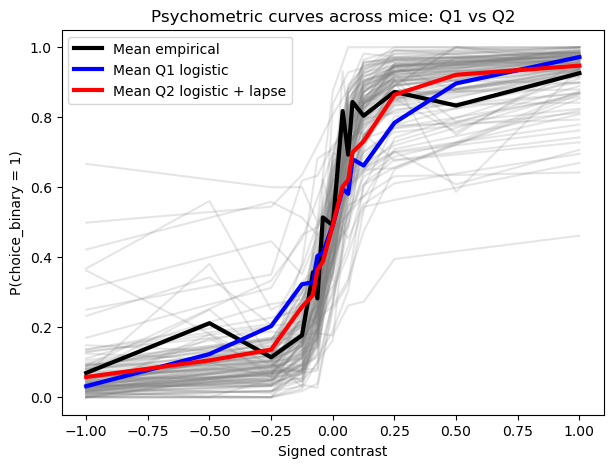

In [118]:
# Add Q2 Logistic + Lapse predictions
all_curves_df['p_test_lapse'] = [
    predict_proba_lapse_model(
        np.array([contrast]),
        mouse_logictic_lapse_models[subject]['params']['bias'],
        mouse_logictic_lapse_models[subject]['params']['contrast_weight'],
        mouse_logictic_lapse_models[subject]['params']['lapse_probability']
    )[0]
    for subject, contrast in zip(
        all_curves_df['subject'],
        all_curves_df['signed_contrast']
    )
]

mean_curve = (
    all_curves_df
    .groupby('signed_contrast', as_index=False)
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),
        mean_q1=('p_test_predicted', 'mean'),
        mean_q2=('p_test_lapse', 'mean')
    )
)

plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q1'],
    color='blue',
    linewidth=3,
    label='Mean Q1 logistic'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q2'],
    color='red',
    linewidth=3,
    label='Mean Q2 logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice: Q1 vs Q2')
plt.legend()
plt.show()

Next plot is for **one selected mouse**, identified by `subject` in Q1.

It compares:

* empirical test data for that mouse,
* the Q1 standard logistic model,
* the Q2 logistic + lapse model.

The curves show how both models predict that mouse’s choices across signed contrast levels.


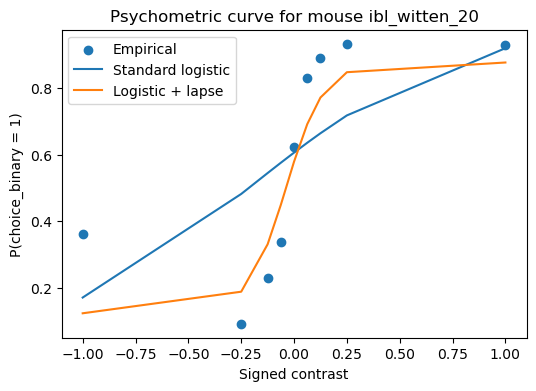

In [119]:
# Logistic + lapse model predictions
lapse_params = mouse_logictic_lapse_models[subject]['params']

p_test_lapse_curve = predict_proba_lapse_model(
    p_test_empirical.index.to_numpy(),
    lapse_params['bias'],
    lapse_params['contrast_weight'],
    lapse_params['lapse_probability']
)

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Standard logistic'
)

plt.plot(
    p_test_empirical.index,
    p_test_lapse_curve,
    label='Logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

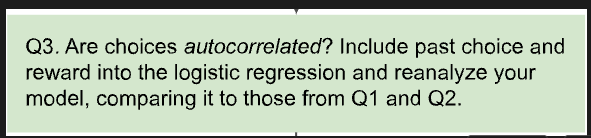

# Q3. Are choices autocorrelated?

### Are the mouse’s choices influenced by past trials?

In Q1, the model used only current stimulus contrast: `choice ~ signed_contrast`

In Q2, the model added lapse probability: `choice ~ signed_contrast + lapse`

In Q3, we need to add behavioral history: `choice ~ signed_contrast + previous_choice + previous_reward`

- `previous_choice` -> what the mouse chose on the previous trial

- `previous_reward` -> whether the mouse was rewarded/correct on the previous trial

Then compare Q3 with Q1 and Q2 using log-likelihood.

If Q3 has better log-likelihood, it means past choice/reward helps predict current choice. 

That would suggest choices are autocorrelated.

### Q3-1. Preparing Previous-Trial Columns for Q3 

- For Q3, I make a new copy called `df_q3` and add past-trial columns only to this copy.

- sort the trials in time order. `sorting` is important because `shift(1)` takes the row directly above as the prev trial.

- group by subject and session so previous trials are calculated separately within each mouse and session.

-  `prev_choice_binary` from the previous trial’s choice.

- `prev_rewarded` from the previous trial’s feedback.

-  remove the first trial of each session because it has no previous trial. 



In [120]:
# Create Q3 copy. Do not change df_q1.
df_q3 = df_q1.copy(deep=True)

#We sort trials are sorted by subject, session_start_time, session, and intervals_0 so the previous-trial columns are calculated in the correct time order.
sort_columns_q3 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q3.columns
]
df_q3 = df_q3.sort_values(sort_columns_q3).copy(deep=True)


# create previous choice column for each mouse and session.
df_q3['prev_choice_binary'] = (
    df_q3
    .groupby(['subject', 'session'])['choice_binary']
    .shift(1)            #shift(1) moves the choices down by one row, so each trial gets the choice from the trial before it

)

# Create previous feedback column for each mouse and session. feedbackType = 0/1 here both
df_q3['prev_feedbackType'] = (
    df_q3
    .groupby(['subject', 'session'])['feedbackType']
    .shift(1)
)

# Convert previous reward to binary:
                            # previous rewarded trial = 1
                            # previous unrewarded/error trial = 0
df_q3['prev_rewarded'] = (df_q3['prev_feedbackType'] == 1).astype(float)

# Remove trials with no previous trial information.
df_q3_model = df_q3.loc[
      df_q3['prev_choice_binary'].notna() &
      df_q3['prev_feedbackType'].notna()
].copy(deep=True)

# Convert previous choice/reward to integer 0/1.
df_q3_model['prev_choice_binary'] = df_q3_model['prev_choice_binary'].astype(int)
df_q3_model['prev_rewarded'] = df_q3_model['prev_rewarded'].astype(int)

display(
    df_q3_model[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded'
    ]].head()
)

print('Q1 rows:', len(df_q1))
print('Q3 rows after removing first trial of each session:', len(df_q3_model))


,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1


Q1 rows: 2132658
Q3 rows after removing first trial of each session: 2129698


### Q3-2. Fit logistic regression with past choice and reward

For each mouse separately, we train a new logistic regression model.

Input variables:

- `signed_contrast`

- `prev_choice_binary`

- `prev_rewarded`

Target variable:

- `choice_binary`

Important interpretation:

- If `prev_choice_weight` is positive, then the mouse tends to repeat the previous choice.

- If `prev_choice_weight` is negative, then the mouse tends to switch away from the previous choice.


In [121]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


mouse_models_q3 = {}

for subject, mouse_data in df_q3_model.groupby('subject'):

    X_q3 = mouse_data[['signed_contrast', 'prev_choice_binary',  'prev_rewarded']]

    y_q3 = mouse_data['choice_binary']

    # Skip a mouse if it does not have both choice classes after preprocessing.
    if y_q3.nunique() < 2:
        continue

    #training 80% of data 
    X_train_q3, X_test_q3, y_train_q3, y_test_q3 = train_test_split(
        X_q3,
        y_q3,
        test_size=0.2,
        random_state=0,
        stratify=y_q3
    )

    model_q3 = LogisticRegression()
    model_q3.fit(X_train_q3, y_train_q3)
    
    class_1_index_q3 = list(model_q3.classes_).index(1)

    #predict testign data 
    p_test_q3 = model_q3.predict_proba(X_test_q3)[:, class_1_index_q3]

    #evaluation testign data 
    log_likelihood_q3 = -log_loss( y_test_q3,  p_test_q3,  labels=[0, 1] )

    mouse_models_q3[subject] = {
        'model': model_q3,
        'X_train': X_train_q3,
        'X_test': X_test_q3,
        'y_train': y_train_q3,
        'y_test': y_test_q3,
        'p_test_q3': p_test_q3,
        'log_likelihood_q3': log_likelihood_q3,
        'bias_q3': model_q3.intercept_[0],
        'contrast_weight_q3': model_q3.coef_[0][0],
        'prev_choice_weight': model_q3.coef_[0][1],
        'prev_reward_weight': model_q3.coef_[0][2]
    }

print('Number of Q3 mouse models:', len(mouse_models_q3))


Number of Q3 mouse models: 119


### Q3-3. Save Q3 model results in a new table

This table is new. It does not change `results_df`, `lapse_results_df`, or `comparison_df`.


In [122]:
q3_results = []

for subject, result in mouse_models_q3.items():
    q3_results.append({
        'subject': subject,
        'bias_q3': result['bias_q3'],
        'contrast_weight_q3': result['contrast_weight_q3'],
        'prev_choice_weight': result['prev_choice_weight'],
        'prev_reward_weight': result['prev_reward_weight'],
        'log_likelihood_q3': result['log_likelihood_q3']
    })

q3_results_df = pd.DataFrame(q3_results)

display(q3_results_df.head())


,subject,bias_q3,contrast_weight_q3,prev_choice_weight,prev_reward_weight,log_likelihood_q3
0,CSHL045,-1.063340,7.593490,1.845844,0.148076,-0.408899
1,CSHL046,-1.281008,4.859110,1.865794,0.372836,-0.434661
2,CSHL047,-1.272828,4.974601,1.416276,-0.561873,-0.410820
3,CSHL049,-0.403213,6.854520,1.457342,0.082990,-0.409152
4,CSHL051,-1.424229,3.490318,2.153235,-0.164136,-0.431315


### Q3-4. Are choices autocorrelated?

Here we look at the `prev_choice_weight`.

- Positive value means current choice depends positively on previous choice.

- Negative value means the mouse tends to switch choices.

- Values close to zero mean weak choice autocorrelation.


In [123]:
print('Mean previous choice weight:', q3_results_df['prev_choice_weight'].mean())
print('Median previous choice weight:', q3_results_df['prev_choice_weight'].median())
print('Number of mice with positive previous choice weight:', (q3_results_df['prev_choice_weight'] > 0).sum())
print('Number of mice with negative previous choice weight:', (q3_results_df['prev_choice_weight'] < 0).sum())


Mean previous choice weight: 1.5569872530736526
Median previous choice weight: 1.50156513693796
Number of mice with positive previous choice weight: 118
Number of mice with negative previous choice weight: 1


### Q3-5. Compare Q3 with Q1 and Q2

Now we compare the held-out log-likelihoods.

New table:

- `comparison_q1_q2_q3_df`

This is a copy-based merge and does not change the old comparison table.


In [124]:
comparison_q1_q2_q3_df = (
    comparison_df.copy(deep=True)
    .merge(q3_results_df, on='subject')
)

comparison_q1_q2_q3_df['q3_improvement_vs_q1'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood']
)

comparison_q1_q2_q3_df['q3_improvement_vs_q2'] = (
    comparison_q1_q2_q3_df['log_likelihood_q3']
    - comparison_q1_q2_q3_df['log_likelihood_lapse']
)

model_columns_q3 = [
    'log_likelihood',
    'log_likelihood_lapse',
    'log_likelihood_q3'
]

comparison_q1_q2_q3_df['best_model'] = (
    comparison_q1_q2_q3_df[model_columns_q3]
    .idxmax(axis=1)
    .replace({
        'log_likelihood': 'Q1 logistic',
        'log_likelihood_lapse': 'Q2 logistic + lapse',
        'log_likelihood_q3': 'Q3 history logistic'
    })
)

print('Mean Q1 log likelihood:', comparison_q1_q2_q3_df['log_likelihood'].mean())
print('Mean Q2 lapse log likelihood:', comparison_q1_q2_q3_df['log_likelihood_lapse'].mean())
print('Mean Q3 history log likelihood:', comparison_q1_q2_q3_df['log_likelihood_q3'].mean())
print()
print('Mean Q3 improvement vs Q1:', comparison_q1_q2_q3_df['q3_improvement_vs_q1'].mean())
print('Mean Q3 improvement vs Q2:', comparison_q1_q2_q3_df['q3_improvement_vs_q2'].mean())

display(
    comparison_q1_q2_q3_df[[
        'subject',
        'log_likelihood',
        'log_likelihood_lapse',
        'log_likelihood_q3',
        'q3_improvement_vs_q1',
        'q3_improvement_vs_q2',
        'best_model'
    ]].head()
)


Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45223541686410507
Mean Q3 history log likelihood: -0.4278173880978828

Mean Q3 improvement vs Q1: 0.05385416690080529
Mean Q3 improvement vs Q2: 0.02441802876622224


,subject,log_likelihood,log_likelihood_lapse,log_likelihood_q3,q3_improvement_vs_q1,q3_improvement_vs_q2,best_model
0,CSHL045,-0.449487,-0.433336,-0.408899,0.040588,0.024437,Q3 history logistic
1,CSHL046,-0.511274,-0.480888,-0.434661,0.076613,0.046227,Q3 history logistic
2,CSHL047,-0.427543,-0.406429,-0.410820,0.016723,-0.004391,Q2 logistic + lapse
3,CSHL049,-0.459950,-0.419286,-0.409152,0.050797,0.010134,Q3 history logistic
4,CSHL051,-0.535279,-0.517182,-0.431315,0.103964,0.085867,Q3 history logistic


### Q3-6. Visualize model comparison

This plot compares Q1, Q2, and Q3 log-likelihoods across mice.

A value closer to `0` is better.


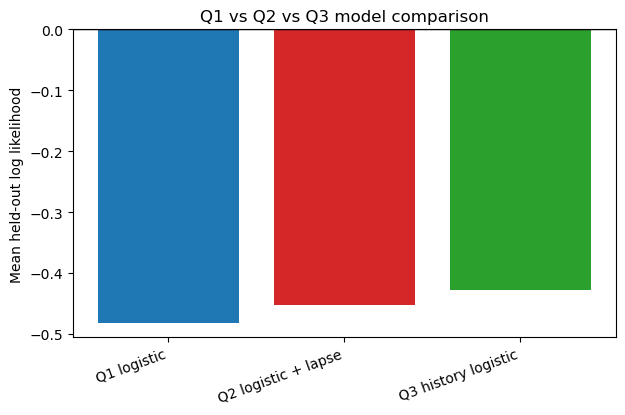

,model,mean_log_likelihood
0,Q1 logistic,-0.481672
1,Q2 logistic + lapse,-0.452235
2,Q3 history logistic,-0.427817


In [125]:
mean_model_scores_q3 = pd.DataFrame({
    'model': [
        'Q1 logistic',
        'Q2 logistic + lapse',
        'Q3 history logistic'
    ],
    'mean_log_likelihood': [
        comparison_q1_q2_q3_df['log_likelihood'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_lapse'].mean(),
        comparison_q1_q2_q3_df['log_likelihood_q3'].mean()
    ]
})

plt.figure(figsize=(7, 4))
plt.bar(
    mean_model_scores_q3['model'],
    mean_model_scores_q3['mean_log_likelihood'],
    color=['tab:blue', 'tab:red', 'tab:green']
)
plt.ylabel('Mean held-out log likelihood')
plt.title('Q1 vs Q2 vs Q3 model comparison')
plt.xticks(rotation=20, ha='right')
plt.axhline(0, color='black', linewidth=1)
plt.show()

display(mean_model_scores_q3)


### Q3 Interpretation

If `prev_choice_weight` is mostly positive, then choices are autocorrelated: the previous choice helps predict the current choice.

If Q3 has higher log-likelihood than Q1 and Q2, then adding past choice and reward improved prediction.

If Q3 does not improve log-likelihood, then the history variables do not improve the held-out prediction for this dataset/model version.


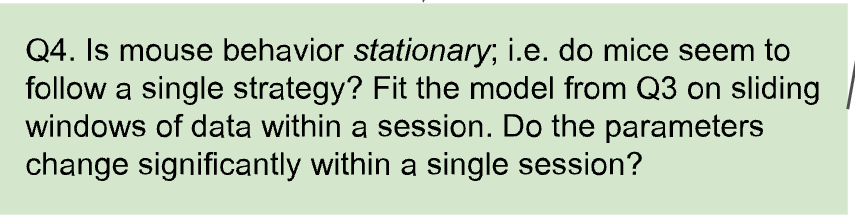

ведёт ли себя мышь одинаково на протяжении всей сессии, или её "стратегия" меняется по ходу дела?

# Q4. Is mouse behavior stationary?
- what does it mean stationary? 

- `stationary` means the mouse’s behavior stays stable over time or mouse use the same strategy during the whole session?

- if the mouse behaves the same at the beginning, middle, and end of the session, behavior is stationary.

- if the mouse changes strategy during the session, behavior is `non-stationary`.


### Do mice follow a single strategy within 1 session?

In Q3, the model used current contrast + past-trial history -> `choice ~ signed_contrast + previous_choice + previous_reward`

In Q4, we ask whether the same model parameters stay stable within 1 session.
For example:

Early in the session the mouse is focused and decides based on the stimulus.
By the middle or end it gets tired, loses motivation, and starts choosing almost randomly.

### Q4-1. Create a copy of Q3 model data

I do not change `df_q3_model`.

For Q4, I make a new copy called `df_q4`.

We use the same Q3 model variables:

- `signed_contrast`

- `prev_choice_binary`

- `prev_rewarded`

- `choice_binary`

In [126]:
# Create Q4 copy. Do not change Q3 data.
df_q4 = df_q3_model.copy(deep=True)

q4_feature_columns = [
    'signed_contrast',
    'prev_choice_binary',
    'prev_rewarded'
]

# Sort trials in time order inside session.
sort_columns_q4 = [
    col for col in ['subject', 'session_start_time', 'session', 'intervals_0']
    if col in df_q4.columns
]
df_q4 = df_q4.sort_values(sort_columns_q4).copy(deep=True)

display(
    df_q4[[
        'subject',
        'session',
        'signed_contrast',
        'choice_binary',
        'prev_choice_binary',
        'prev_rewarded'  
    ]].head()
)

print('Q4 rows:', len(df_q4))

,subject,session,signed_contrast,choice_binary,prev_choice_binary,prev_rewarded
41825,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,0.0625,1,1,0
41826,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.1250,1,1,1
41827,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,1,1,0
41828,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.0000,0,1,0
41829,CSHL045,85501aad-64e6-4137-a44e-2c933c9eec5f,-0.2500,0,0,1


Q4 rows: 2129698


### Q4-2. We need one session for sliding-window analysis.

Requirements:

1. enough trials  
2. both choices: `0` and `1`    #q4_session_summary
3. largest valid session #at least 200 trials

- choose 1 session with enough trials

- Instead of 1 model for the whole session, we cut it into sliding windows like 150–200 trials each, shifting by 50 trials at a time 

- Check and Refit the same model from Q3 -> contrast + bias + previous choice + previous reward IN EACH WINDOW. 

- Track how the coefficients (bias, contrast weight etc) change from window to window.

- compare the parameters across time (like test Cochrans Q)

If the parameters change a lot within the session, then behavior may be **non-stationary**.

write why scipy not skilearn linear regression?

In [127]:
import statsmodels.api as sm
from scipy import stats

In [128]:
# ШАГ 1. Lets settings sliding-window
# WINDOW_SIZE = how many trials go into one window.
# STEP = how far the window moves each time.
# PARAM_NAMES = model parameters we will track over time.
WINDOW_SIZE = 200
STEP = 50
PARAM_NAMES = ['bias'] + q4_feature_columns

In [129]:
# Шаг 2. This function fits the Q3 logistic model inside 1 window.
# It returns coefficients and standard errors, потому что we need standard errors for the stationarity test.

def fit_window_logistic(df_window):

    X = sm.add_constant(df_window[q4_feature_columns].values)  #import statsmodels.api as sm
    y = df_window['choice_binary'].values

    # Skip window if it does not have both choices 0 and 1.
    if len(np.unique(y)) < 2:
        return None
    
    try:
        result = sm.Logit(y, X).fit(disp=0)
        return result.params, result.bse
    except Exception:
        return None


# 3. Choose example mice and sessions.
# We take 3 best mice from Q3 and choose the longest session for each.
# Long sessions are needed because sliding windows need enough trials.
example_mice = (
    q3_results_df.sort_values('log_likelihood_q3', ascending=False)['subject'].head(2)
)

example_sessions = {
    subject: df_q4.loc[df_q4['subject'] == subject, 'session'].value_counts().idxmax()
    for subject in example_mice
}


WINDOW_SIZE = 200
STEP = 50

window 1: trials 0-199

window 2: trials 50-249

window 3: trials 100-299

In [130]:
# 4. Fit Q3 model in sliding windows.
# Each window gives 1 set of parameters. If parameters change across windows, behavior may be non-stationary.
window_results = {}

for subject, session in example_sessions.items(): #For each selected mouse/session, split the session into sliding windows.

    df_sess = (
        df_q4[(df_q4['subject'] == subject) & (df_q4['session'] == session)]
        .sort_values('intervals_0')
        .reset_index(drop=True)
    )

    rows = []

    for start in range(0, len(df_sess) - WINDOW_SIZE + 1, STEP): #Move a sliding window through the session.

        window = df_sess.iloc[start:start + WINDOW_SIZE] #Take the trials inside the current window.
       
        fit = fit_window_logistic(window)   #Fit Q3 logistic regression on this window.

        if fit is None:
            continue

        params, se = fit
        row = {'window_center': start + WINDOW_SIZE // 2} #We save window_center because it tells us where this window is located in the session.

        for name, p, s in zip(PARAM_NAMES, params, se): #Match each parameter name with its estimate and standard error.
            row[f'{name}_est'] = p
            row[f'{name}_se'] = s

        rows.append(row)

    window_results[(subject, session)] = pd.DataFrame(rows)


In [131]:
# Combine all window result tables into one table
window_results_table = []

for (subject, session), df_win in window_results.items():
    df_temp = df_win.copy()
    df_temp['subject'] = subject
    df_temp['session'] = session
    window_results_table.append(df_temp)

window_results_table = pd.concat(window_results_table, ignore_index=True)

display(window_results_table.head())

,window_center,bias_est,bias_se,signed_contrast_est,signed_contrast_se,prev_choice_binary_est,prev_choice_binary_se,prev_rewarded_est,prev_rewarded_se,subject,session
0,100,1.055994,1.590004,40.811724,8.826078,0.331439,0.739312,-1.140068,1.591583,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
1,150,-0.356147,2.580908,29.879020,5.580264,1.093511,0.652617,0.009867,2.553405,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
2,200,-3.427970,1.535703,28.636608,5.390141,1.234036,0.627839,3.095242,1.482343,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
3,250,-0.070402,0.990381,21.754248,3.746165,0.260570,0.522809,0.009504,0.971278,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32
4,300,-0.125038,0.925962,19.557239,3.273941,0.447227,0.483663,0.293311,0.909355,ZM_1085,8c985920-2434-483f-a99e-d143e7921b32


window_center   bias_est   contrast_weight_est   prev_choice_weight_est
100             -0.2       4.5                   0.3
150             -0.1       4.2                   0.5
200              0.0       3.8                   0.8

- This code moves a 200-trial window across the session.
- In each window, it fits Q3 logistic regression.
- Then it saves the parameters from each window so we can check if they change over time.

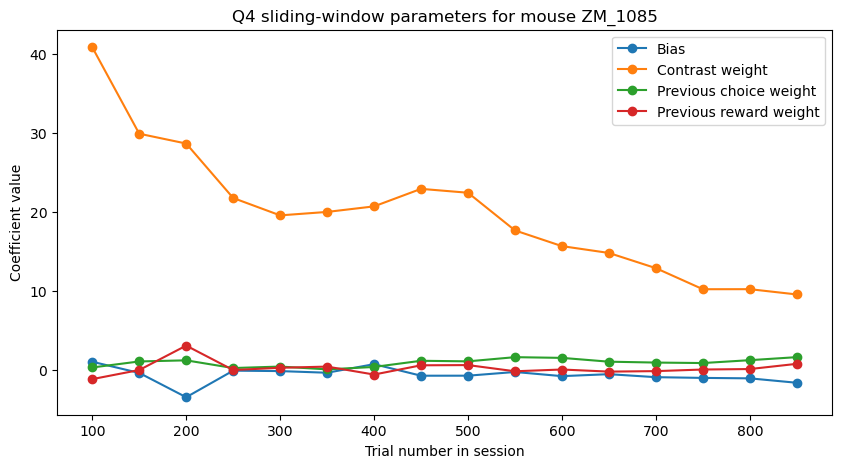

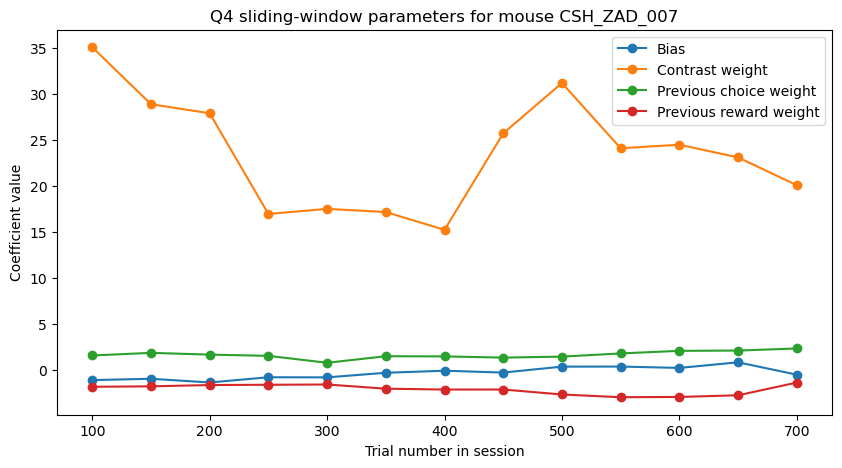

In [132]:
for subject in window_results_table['subject'].unique():

    mouse_table = window_results_table[
        window_results_table['subject'] == subject
    ]

    plt.figure(figsize=(10, 5))

    plt.plot(mouse_table['window_center'], mouse_table['bias_est'], marker='o', label='Bias')
    plt.plot(mouse_table['window_center'], mouse_table['signed_contrast_est'], marker='o', label='Contrast weight')
    plt.plot(mouse_table['window_center'], mouse_table['prev_choice_binary_est'], marker='o', label='Previous choice weight')
    plt.plot(mouse_table['window_center'], mouse_table['prev_rewarded_est'], marker='o', label='Previous reward weight')

    plt.xlabel('Trial number in session')
    plt.ylabel('Coefficient value')
    plt.title(f'Q4 sliding-window parameters for mouse {subject}')
    plt.legend()
    plt.show()

Cochran-style heterogeneity statistic Q делает одну конкретную вещь:

- собирает различия между коэффициентами из всех окон в одно число и проверяет, слишком ли эти различия большие, чтобы объяснить их обычной статистической ошибкой.

- Пусть в каждом окне получен коэффициент: βi и его стандартная ошибка = SEi 

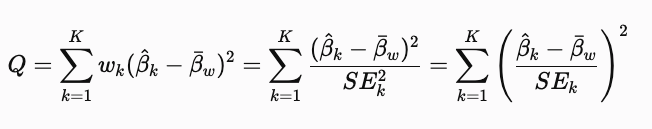

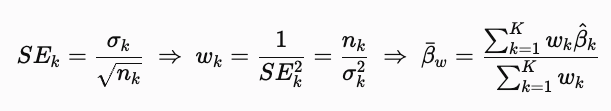

In [133]:
# 5. Test whether coefficients change across windows.
# This is a Cochran-style weighted test.
# p_value < 0.05 means the parameter changed significantly over time.
stationarity_results = []

for (subject, session), df_win in window_results.items():
    
    for name in PARAM_NAMES:          #contrast, previous_choice, previous_reward.
        est = df_win[f'{name}_est'].values #get оценки выбранного коэффициента из всех окон.
        se = df_win[f'{name}_se'].values     #берёт standard error этого коэффициента для каждого окна.

        weights = 1 / se**2     #calculate the weights. Чем меньше ошибка, тем больше доверие к оценке. 
        mean_est = np.sum(weights * est) / np.sum(weights)  #считает общий взвешенный средний коэффициент

        Q = np.sum(weights * (est - mean_est) ** 2)    #измеряет, насколько коэффициенты разных окон отличаются от общего среднего
        dof = len(est) - 1           #число степеней свободы K — количество окон.
        p = stats.chi2.sf(Q, dof)    #вычисляет вероятность получить такой большой Q, если коэффициент на самом деле не менялся. p value

        stationarity_results.append({
            'subject': subject,
            'parameter': name,
            'p_value': p,
            'significant_change': p < 0.05
        })


# 6. Final stationarity result table.
# If significant_change is True, that parameter is not stable across the session.
stationarity_table = pd.DataFrame(stationarity_results)
display(stationarity_table)

,subject,parameter,p_value,significant_change
0,ZM_1085,bias,7.695826e-01,False
1,ZM_1085,signed_contrast,7.642346e-08,True
2,ZM_1085,prev_choice_binary,5.185105e-01,False
3,ZM_1085,prev_rewarded,9.507211e-01,False
4,CSH_ZAD_007,bias,5.208386e-01,False
5,CSH_ZAD_007,signed_contrast,4.193079e-02,True
6,CSH_ZAD_007,prev_choice_binary,9.572800e-01,False
7,CSH_ZAD_007,prev_rewarded,9.558280e-01,False


### Null hypothesis

$$
H_0:\ \beta_1=\beta_2=\cdots=\beta_K
$$

**The coefficient is the same across all windows.**
**Коэффициент одинаковый во всех окнах.**

| p-value       | Interpretation                                                                                                                                                         |
| ------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| $p < 0.05$    | **Reject $H_0$:** the coefficient changed over time. <br> **Отклоняем $H_0$:** коэффициент менялся со временем.                                                        |
| $p \geq 0.05$ | **Fail to reject $H_0$:** there is not enough evidence that the coefficient changed. <br> **Не отклоняем $H_0$:** недостаточно доказательств, что коэффициент менялся. |


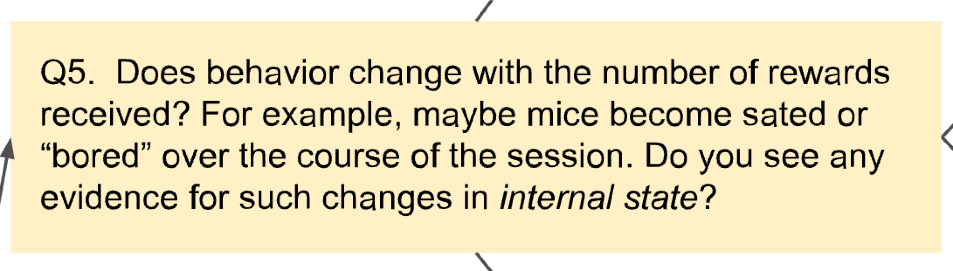

# Q5. Does behavior change with the number of rewards received?

### Do mice become sated or bored over the course of the session? Need a evidence for such changes in internal state

Here we have to test whether the mouse's choices change as the mouse receives more rewards in a session.

Internal state - mouse’s condition inside its body or brain at a particular moment(bored, tired, sated сытый).

- At the beginning of a session, the mouse may be motivated.

- After many rewards, the mouse may become sated, tired, or bored.

- If this is true, reward history should help predict choices.

$$
\begin{aligned}
P(\mathrm{choice}=1)=\sigma\Bigl(
&\beta_0+\beta_1\,\mathrm{signed\_contrast} \\
&+\beta_2\,\mathrm{previous\_choice} \\
&+\beta_3\,\mathrm{previous\_reward} \\
&+\beta_4\,\mathrm{trial\_fraction} \\
&+\beta_5\,\mathrm{reward\_fraction} \\
&+\beta_6\,(\mathrm{trial\_fraction}\times\mathrm{signed\_contrast}) \\
&+\beta_7\,(\mathrm{reward\_fraction}\times\mathrm{signed\_contrast})
\Bigr)
\end{aligned}
$$


### Q5-1. Create a copy from Q3 data

I create a new copy called `df_q5`.

For Q5, we need:

- current choice: `choice_binary`

- current stimulus: `signed_contrast`

- previous choice: `prev_choice_binary`

- previous reward: `prev_rewarded`

- rewards received so far in the session

Important: rewards so far must be counted **before** the current trial.


In [134]:
df_q5 = df_q3.copy()  # already has prev_choice / prev_reward / prev_choice_x_reward from Q3 
df_q5 = df_q5.sort_values(
    ['subject', 'session', 'intervals_0']
).copy()

In [135]:
q5_group_cols = ['subject', 'session']

### Q5-2. Create Column Trial Fraction

We create `trial_number` inside each session. 
- For each mouse and session, trials are counted in order: `0, 1, 2, 3...`. 

- For every new session, the count starts again from `0`. 

- This helps us know whether a trial is at the beginning, middle, or end of the session.

subject   session   trial_number
mouse1    sess1     0
mouse1    sess1     1
mouse1    sess1     2
mouse1    sess1     3

In [136]:
df_q5['trial_number'] = (
    df_q5
    .groupby(q5_group_cols)
    .cumcount()
)

display(df_q5['trial_number'])

55855         0
55856         1
55857         2
55858         3
55859         4
           ... 
5530751    1048
5530752    1049
5530753    1050
5530754    1051
5530755    1052
Name: trial_number, Length: 2132658, dtype: int64

### trial_fraction

`trial_fraction` shows where a trial is inside the session.

| Value | Meaning |
|---:|---|
| `0` | beginning of the session |
| `0.5` | middle of the session |
| `1` | end of the session |

Example:

| `trial_number` | `trial_fraction` |
|---:|---:|
| `0` | `0.00` |
| `50` | `0.50` |
| `99` | `1.00` |

Formula:

```text
- trial_fraction = trial_number / maximum trial_number in that session

- We use trial_fraction to check whether behavior changes because the session is near the end, or because the mouse has received many rewards.

trial_fraction нужен, чтобы понять:
- мышь меняет поведение потому что уже конец session,
- потому что она получила много rewards.

In [137]:
df_q5['trial_fraction'] = (
    df_q5['trial_number']/ df_q5.groupby(q5_group_cols)['trial_number'].transform('max')
)

display(df_q5['trial_fraction'])

55855      0.000000
55856      0.001712
55857      0.003425
55858      0.005137
55859      0.006849
             ...   
5530751    0.996198
5530752    0.997148
5530753    0.998099
5530754    0.999049
5530755    1.000000
Name: trial_fraction, Length: 2132658, dtype: float64

### Q5-3. Create Column Reward Fraction

reward_fraction means:

- how many rewards the mouse already received in this session

- divided by total rewards in that session


reward_fraction = how many rewards were received before this trial

In [138]:
# create rewarded column -> rewarded = 1 if current trial was rewarded, otherwise 0.
df_q5['rewarded'] = (df_q5['feedbackType'] == 1).astype(int)

display(df_q5['rewarded'])

55855      1
55856      0
55857      1
55858      1
55859      1
          ..
5530751    1
5530752    1
5530753    1
5530754    1
5530755    1
Name: rewarded, Length: 2132658, dtype: int64

In [139]:
# Count how many rewards happened before the current trial. cumsum() includes current trial, so we subtract current reward.
df_q5['cum_rewards_before'] = (
    df_q5.groupby(q5_group_cols)['rewarded'].cumsum() - df_q5['rewarded']
)

# Count total rewards in each session.
total_rewards = (
    df_q5.groupby(q5_group_cols)['rewarded'].transform('sum')
)

print(total_rewards)


# reward_fraction shows how many session rewards were already received.
# 0 = no rewards received yet, 1 = all rewards already received.
df_q5['reward_fraction'] = (df_q5['cum_rewards_before']/ total_rewards.replace(0, np.nan))

display(df_q5[['rewarded', 'cum_rewards_before','reward_fraction']])

# Example: ID=55858 -> cum_rewards_before = 1 -> total_rewards = 488
# reward_fraction = cum_rewards_before / total_rewards
# reward_fraction = 1 / 488 = 0.002049
# Before this trial, the mouse had received 1 reward out of 488 total session rewards. So it is very early in reward accumulation.


55855      489
55856      489
55857      489
55858      489
55859      489
          ... 
5530751    903
5530752    903
5530753    903
5530754    903
5530755    903
Name: rewarded, Length: 2132658, dtype: int64


,rewarded,cum_rewards_before,reward_fraction
55855,1,0,0.000000
55856,0,1,0.002045
55857,1,1,0.002045
55858,1,2,0.004090
55859,1,3,0.006135
...,...,...,...
5530751,1,898,0.994463
5530752,1,899,0.995570
5530753,1,900,0.996678
5530754,1,901,0.997785


### Q5-4. Create Column Interaction features 

Next, we should add the Q5 reward-state variables into the model.

Now we already have:

- `trial_fraction` — how far the trial is inside the session

- `reward_fraction` — how many rewards the mouse already received before this trial

Next, we create interaction terms with `signed_contrast`.

This is important 

To read an interaction, use this rule:

A × B means:
Does the effect of A change depending on B?
or Does B change how A affects choice?

### `reward_fraction × signed_contrast`

After many rewards, does the mouse use contrast better or worse?

In other words:  Does the mouse react to the stimulus differently after receiving many rewards?

Example:

At the beginning of the session, contrast may strongly affect choice.

After many rewards, contrast may affect choice more weakly.

### `trial_fraction × signed_contrast`

This interaction checks whether the mouse uses contrast differently from the beginning to the end of the session.

In other words:    Does the mouse use contrast better or worse toward the end of the session?

Example:

At the beginning of the session, the mouse may respond strongly to contrast.

At the end of the session, the mouse may be tired, so contrast may affect choice less strongly.

### Important because reward accumulation may not only shift the mouse’s choice bias, 

but also change how strongly the mouse responds to stimulus contrast.

Then we fit a new logistic regression model using:

- `signed_contrast`

- `prev_choice_binary`

- `prev_rewarded`

- `trial_fraction`

- `reward_fraction`

- `trial_fraction_x_contrast`

- `reward_fraction_x_contrast`

Finally, we compare Q5 with Q4 using test data log-likelihood.

If Q5 has better log-likelihood than Q4, then reward count or session progress helps explain mouse behavior.

| Variable | What the model tests | Meaning |
|---|---|---|
| `trial_fraction` | Does choice change as `trial_fraction` goes from `0` to `1`? | Does behavior change from start to end of session? |
| `trial_fraction` | Does the mouse become more biased toward one choice later in the session? | Checks time/fatigue/boredom effect on choice bias. |
| `reward_fraction` | Does choice change as `reward_fraction` goes from `0` to `1`? | Does behavior change as the mouse receives more rewards? |
| `reward_fraction` | Does the mouse become more biased toward one choice after many rewards? | Checks possible satiety/reward accumulation effect on choice bias. |
| `trial_fraction × signed_contrast` | Does the effect of contrast change as `trial_fraction` goes from `0` to `1`? | Does stimulus sensitivity change from start to end of session? |
| `trial_fraction × signed_contrast` | Does the mouse use contrast less strongly later in the session? | Checks whether time/fatigue changes sensitivity to stimulus. |
| `reward_fraction × signed_contrast` | Does the effect of contrast change as `reward_fraction` goes from `0` to `1`? | Does stimulus sensitivity change as the mouse receives more rewards? |
| `reward_fraction × signed_contrast` | Does the mouse use contrast less strongly after many rewards? | Checks whether satiety/reward accumulation changes sensitivity to stimulus. |

In [140]:
# Remove rows where trial_fraction or reward_fraction could not be calculated.
df_q5 = df_q5.dropna(
    subset=['trial_fraction', 'reward_fraction']
).copy()

# Interaction 1:
# Does the mouse use contrast differently from the beginning to the end of the session?
df_q5['trial_fraction_x_contrast'] = (
    df_q5['trial_fraction'] * df_q5['signed_contrast']
)

# Interaction 2:
# Does the mouse use contrast differently after receiving many rewards?
df_q5['reward_fraction_x_contrast'] = (
    df_q5['reward_fraction'] * df_q5['signed_contrast']
)


- trial_fraction = сколько session уже прошло

- reward_fraction = сколько rewards мышь уже получила

- если поведение изменилось, мы не знаем почему: из-за времени? или из-за rewards? насколько trial_fraction и reward_fraction похожи

- Если correlation высокая: они почти одно и то же то трудно сказать, что именно влияет

- Если correlation не очень высокая: reward_fraction может давать отдельную информацию


Мы проверяем correlation

In [141]:
# Check how similar trial progress and reward progress are.
# If correlation is high, time and reward count are hard to separate.

q5_time_reward_corr = (
    df_q5[['trial_fraction', 'reward_fraction']]
    .corr()
    .iloc[0, 1]
)

print("Trials with valid Q5 state features:", df_q5.shape)
print("Correlation between trial_fraction and reward_fraction:", round(q5_time_reward_corr, 3))

# Clear interpretation of correlation between trial_fraction and reward_fraction

print("Correlation:", round(q5_time_reward_corr, 3))

if q5_time_reward_corr > 0.9:
    print("Very high correlation.")
    print("trial_fraction and reward_fraction are almost the same signal.")
    print("It is hard to separate reward effect from time/session-progress effect.")

elif q5_time_reward_corr > 0.6:
    print("Moderate/high correlation.")
    print("trial_fraction and reward_fraction are related.")
    print("Reward effect and time effect may be partly mixed.")

else:
    print("Low correlation.")
    print("trial_fraction and reward_fraction are different enough.")
    print("Reward effect is easier to separate from time/session-progress effect.")



Trials with valid Q5 state features: (2132658, 46)
Correlation between trial_fraction and reward_fraction: 0.998
Correlation: 0.998
Very high correlation.
trial_fraction and reward_fraction are almost the same signal.
It is hard to separate reward effect from time/session-progress effect.


In [142]:
# Q5. Fit logistic regression with reward/time state variables for each mouse

# These are the Q5 model inputs.
# Q3 features + time/reward state features.
q5_state_features = [
    'signed_contrast',
    'prev_choice_binary',
    'prev_rewarded',
    'trial_fraction',
    'reward_fraction',
    'trial_fraction_x_contrast',
    'reward_fraction_x_contrast'
]

df_q5 = df_q5.dropna(
    subset=q5_state_features + ['choice_binary']
).copy()

print("Q5 clean data shape:", df_q5.shape)
print(df_q5[q5_state_features].isna().sum())


# Save Q5 model results for each mouse.
q5_state_models = {}

for subject, mouse_data in df_q5.groupby('subject'):

    X_q5 = mouse_data[q5_state_features]
    y_q5 = mouse_data['choice_binary']

    # Skip mice with too few trials.
    if len(y_q5) < 100:
        continue

    # Skip mice that only have one choice class.
    # Logistic regression needs both choices: 0 and 1.
    if y_q5.nunique() < 2:
        continue

    if y_q5.value_counts().min() < 2:
        continue

    # Same 80/20 train-test split as before.
    X_train_q5, X_test_q5, y_train_q5, y_test_q5 = train_test_split(
        X_q5,
        y_q5,
        test_size=0.2,
        random_state=0,
        stratify=y_q5
    )

    # Fit Q5 logistic regression.
    model_q5 = LogisticRegression()

    model_q5.fit(X_train_q5, y_train_q5)

    # Predict probabilities on test data.
    p_test_q5 = model_q5.predict_proba(X_test_q5)[:, 1]

    # Calculate held-out log likelihood.
    log_likelihood_q5 = -log_loss(y_test_q5, p_test_q5)

    # Save all important model results.
    q5_state_models[subject] = {
        'model': model_q5,
        'bias_q5': model_q5.intercept_[0],
        'contrast_weight_q5': model_q5.coef_[0][0],
        'prev_choice_weight_q5': model_q5.coef_[0][1],
        'prev_reward_weight_q5': model_q5.coef_[0][2],
        'trial_fraction_weight_q5': model_q5.coef_[0][3],
        'reward_fraction_weight_q5': model_q5.coef_[0][4],
        'trial_fraction_x_contrast_weight_q5': model_q5.coef_[0][5],
        'reward_fraction_x_contrast_weight_q5': model_q5.coef_[0][6],
        'n_train': len(y_train_q5),
        'n_test': len(y_test_q5),
        'log_likelihood_q5': log_likelihood_q5
    }

print(
    'Fit Q5 state-augmented logistic regression for',
    len(q5_state_models),
    'mice out of',
    df_q5['subject'].nunique()
)

Q5 clean data shape: (2129698, 46)
signed_contrast               0
prev_choice_binary            0
prev_rewarded                 0
trial_fraction                0
reward_fraction               0
trial_fraction_x_contrast     0
reward_fraction_x_contrast    0
dtype: int64
Fit Q5 state-augmented logistic regression for 119 mice out of 119


In [143]:
# Create Q5 state table
state_table = pd.DataFrame({
    subject: {k: v for k, v in result.items() if k != 'model'}
    for subject, result in q5_state_models.items()
}).T

# Compare Q5 with Q3
state_vs_history = q3_results_df[['subject', 'log_likelihood_q3']].merge(
    state_table[['log_likelihood_q5']],
    left_on='subject',
    right_index=True,
    how='inner'
)

state_vs_history['improvement'] = (
    state_vs_history['log_likelihood_q5']
    - state_vs_history['log_likelihood_q3']
)

print(f"Mean held-out LL, Q3 (contrast + history): {state_vs_history['log_likelihood_q3'].mean():.3f}")
print(f"Mean held-out LL, Q5 (Q3 + trial/reward fraction): {state_vs_history['log_likelihood_q5'].mean():.3f}")

print(
    "Mice where adding reward/time terms improves the fit:",
    (state_vs_history['improvement'] > 0).sum(),
    "/",
    len(state_vs_history)
)

display(
    state_vs_history
    .sort_values('improvement', ascending=False)
    .head(10)
)

Mean held-out LL, Q3 (contrast + history): -0.428
Mean held-out LL, Q5 (Q3 + trial/reward fraction): -0.424
Mice where adding reward/time terms improves the fit: 73 / 119


,subject,log_likelihood_q3,log_likelihood_q5,improvement
85,ZM_1084,-0.369194,-0.309037,0.060157
48,KS002,-0.616261,-0.572060,0.044202
96,ZM_1743,-0.429922,-0.386914,0.043008
35,DY_006,-0.408258,-0.371668,0.036590
52,KS015,-0.350272,-0.315487,0.034785
26,CSH_ZAD_006,-0.370333,-0.336477,0.033856
31,CSH_ZAD_022,-0.451205,-0.422114,0.029091
56,KS020,-0.464683,-0.438940,0.025743
86,ZM_1085,-0.273565,-0.247994,0.025570
12,CSHL_001,-0.401223,-0.376017,0.025206


### Q5-4. Save results in a new table

This is the main Q5 result table.

Positive `q5_improvement_vs_baseline` means the reward-count model predicts better than the Q3-style baseline model.


In [144]:
# Q5 results table
# This table compares:
# 1. baseline model
# 2. reward-count model
# 3. time-control model

q5_state_results = []

for subject, result in q5_state_models.items():

    q5_state_results.append({
        'subject': subject,

        'log_likelihood_q5': result['log_likelihood_q5'],

        'bias_q5': result['bias_q5'],
        'contrast_weight_q5': result['contrast_weight_q5'],
        'prev_choice_weight_q5': result['prev_choice_weight_q5'],
        'prev_reward_weight_q5': result['prev_reward_weight_q5'],

        'trial_fraction_weight_q5': result['trial_fraction_weight_q5'],
        'reward_fraction_weight_q5': result['reward_fraction_weight_q5'],
        'trial_fraction_x_contrast_weight_q5': result['trial_fraction_x_contrast_weight_q5'],
        'reward_fraction_x_contrast_weight_q5': result['reward_fraction_x_contrast_weight_q5'],

        'n_train': result['n_train'],
        'n_test': result['n_test']
    })

q5_state_results_df = pd.DataFrame(q5_state_results)

display(q5_state_results_df.head())

print('Mean Q5 log likelihood:', q5_state_results_df['log_likelihood_q5'].mean())

,subject,log_likelihood_q5,bias_q5,contrast_weight_q5,prev_choice_weight_q5,prev_reward_weight_q5,trial_fraction_weight_q5,reward_fraction_weight_q5,trial_fraction_x_contrast_weight_q5,reward_fraction_x_contrast_weight_q5,n_train,n_test
0,CSHL045,-0.389871,-0.961224,6.439781,1.838723,0.098155,0.717739,-0.862280,0.954910,0.820533,14346,3587
1,CSHL046,-0.431764,-1.041649,6.448803,1.903601,0.323497,-0.145625,-0.278059,-1.208363,-1.586172,11595,2899
2,CSHL047,-0.407891,-1.186170,5.134164,1.408294,-0.569233,-0.292750,0.160313,0.186206,-0.555027,12898,3225
3,CSHL049,-0.405104,-0.285663,7.286602,1.488091,0.069136,0.542664,-0.816292,0.210606,-0.971055,12478,3120
4,CSHL051,-0.436836,-1.443982,4.352907,2.174330,-0.132453,2.986911,-3.003029,0.150995,-1.732908,12105,3027


Mean Q5 log likelihood: -0.42375076723234106


In [145]:
q5_vs_q3_df = q3_results_df[['subject', 'log_likelihood_q3']].merge(
    q5_state_results_df[['subject', 'log_likelihood_q5']],
    on='subject',
    how='inner'
)

q5_vs_q3_df['q5_improvement_vs_q3'] = (
    q5_vs_q3_df['log_likelihood_q5']
    - q5_vs_q3_df['log_likelihood_q3']
)

display(q5_vs_q3_df.head())

print('Mean Q3 log likelihood:', q5_vs_q3_df['log_likelihood_q3'].mean())
print('Mean Q5 log likelihood:', q5_vs_q3_df['log_likelihood_q5'].mean())
print('Mean Q5 improvement:', q5_vs_q3_df['q5_improvement_vs_q3'].mean())

,subject,log_likelihood_q3,log_likelihood_q5,q5_improvement_vs_q3
0,CSHL045,-0.408899,-0.389871,0.019028
1,CSHL046,-0.434661,-0.431764,0.002897
2,CSHL047,-0.410820,-0.407891,0.002928
3,CSHL049,-0.409152,-0.405104,0.004048
4,CSHL051,-0.431315,-0.436836,-0.005522


Mean Q3 log likelihood: -0.4278173880978828
Mean Q5 log likelihood: -0.42375076723234106
Mean Q5 improvement: 0.0040666208655417155


### Q5-5. Visualize model improvement

This plot directly answers whether reward count improves prediction.

- Positive values mean reward count improved the model.
- Negative values mean reward count made prediction worse.

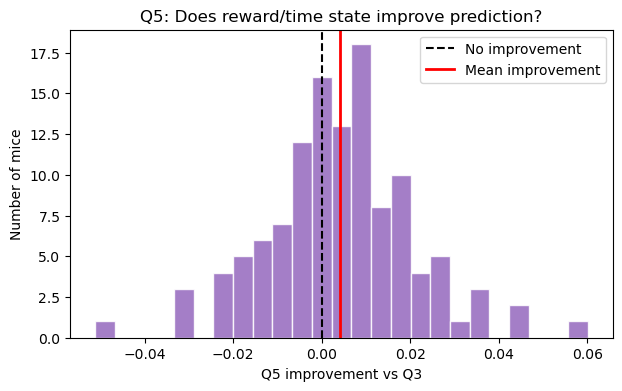

Mean improvement: 0.0040666208655417155
Mice improved: 73 / 119


In [146]:
# Q5-5. Visualize model improvement

q5_plot_df = q5_vs_q3_df.copy()

mean_improvement = q5_plot_df['q5_improvement_vs_q3'].mean()
n_improved = (q5_plot_df['q5_improvement_vs_q3'] > 0).sum()
n_total = len(q5_plot_df)

plt.figure(figsize=(7, 4))

plt.hist(
    q5_plot_df['q5_improvement_vs_q3'],
    bins=25,
    color='tab:purple',
    edgecolor='white',
    alpha=0.85
)

plt.axvline(0, color='black', linestyle='--', label='No improvement')
plt.axvline(mean_improvement, color='red', linewidth=2, label='Mean improvement')

plt.xlabel('Q5 improvement vs Q3')
plt.ylabel('Number of mice')
plt.title('Q5: Does reward/time state improve prediction?')
plt.legend()
plt.show()

print('Mean improvement:', mean_improvement)
print('Mice improved:', n_improved, '/', n_total)

state_fits -> your variable is q5_state_models

history_table/history_ll -> your Q3 table is q3_results_df/log_likelihood_q3

test_ll_per_trial_state -> your Q5 column is log_likelihood_q5

In [147]:
# Q5 final conclusion for current Q5 state model

mean_q5_improvement = q5_vs_q3_df['q5_improvement_vs_q3'].mean()

mean_reward_weight = q5_state_results_df['reward_fraction_weight_q5'].mean()
mean_trial_weight = q5_state_results_df['trial_fraction_weight_q5'].mean()

mean_reward_contrast_weight = q5_state_results_df['reward_fraction_x_contrast_weight_q5'].mean()
mean_trial_contrast_weight = q5_state_results_df['trial_fraction_x_contrast_weight_q5'].mean()

print('Mean Q5 improvement vs Q3:', mean_q5_improvement)
print('Mean reward-fraction weight:', mean_reward_weight)
print('Mean trial-fraction weight:', mean_trial_weight)
print('Mean reward x contrast weight:', mean_reward_contrast_weight)
print('Mean trial x contrast weight:', mean_trial_contrast_weight)
print()

if mean_q5_improvement > 0:
    print('Q5 conclusion: reward/time state variables improve prediction compared with Q3.')
else:
    print('Q5 conclusion: reward/time state variables do not improve prediction compared with Q3 on average.')

if abs(mean_reward_weight) > 0.05 or abs(mean_reward_contrast_weight) > 0.05:
    print('Interpretation: reward fraction has a noticeable effect in the Q5 model.')
    print('This is evidence that behavior may change with accumulated rewards.')
else:
    print('Interpretation: reward fraction effect is weak in the Q5 model.')

if abs(mean_trial_weight) > 0.05 or abs(mean_trial_contrast_weight) > 0.05:
    print('Trial/session progress also has a noticeable effect.')
    print('So reward effects and time-in-session effects may be mixed.')
else:
    print('Trial/session progress effect is weak.')

Mean Q5 improvement vs Q3: 0.0040666208655417155
Mean reward-fraction weight: -0.28860586556547196
Mean trial-fraction weight: 0.23840216648084994
Mean reward x contrast weight: -0.45250202768691605
Mean trial x contrast weight: 0.06340923911968177

Q5 conclusion: reward/time state variables improve prediction compared with Q3.
Interpretation: reward fraction has a noticeable effect in the Q5 model.
This is evidence that behavior may change with accumulated rewards.
Trial/session progress also has a noticeable effect.
So reward effects and time-in-session effects may be mixed.


### Q5-8. Final interpretation

Use these rules:

1. If `q5_improvement_vs_baseline` is positive, rewards-so-far improves prediction.

2. If `reward_count_weight_q5` is far from zero, reward count changes choice behavior.

3. If the reward-count effect remains after controlling for trial number, this is stronger evidence for internal state.
4. If the effect disappears after trial-number control, then the change may mostly reflect time in session, fatigue, or boredom.

This analysis gives evidence about internal state, but it does not prove the exact cause. Satiety, boredom, fatigue, and motivation can look similar behaviorally.


## My NOTES

### `previous_choice`

Does the mouse repeat its previous choice?

Example:   If the mouse chose right on the previous trial, does it choose right again?

---

### `previous_reward`

Does the previous reward affect the next choice?

Example:  If the mouse was rewarded on the previous trial, does it change or repeat its choice?

---

### `previous_choice × previous_reward`

This interaction checks whether the mouse uses the result of the previous trial to decide what to do next.

Reason:   The previous choice may not matter the same way after reward and after no reward.

Example: 

- If the mouse chose right on the previous trial and received a reward, it may choose right again.

- If the mouse chose right on the previous trial but did not receive a reward, it may switch to the other side.

So this interaction asks:

- Does reward make the mouse repeat the previous choice, and does no reward make the mouse switch?

This is called a win-stay / lose-switch strategy.

### `previous_choice × previous_reward`

Эта interaction проверяет, использует ли мышь результат предыдущего trial, чтобы решить, что делать дальше.

Причина:

Предыдущий выбор может влиять по-разному после reward и после no reward.

Пример:

Если мышь выбрала right на предыдущем trial и получила reward, она может снова выбрать right.

Если мышь выбрала right на предыдущем trial, но не получила reward, она может переключиться на другую сторону.

То есть эта interaction спрашивает:

Делает ли reward мышь более склонной повторить предыдущий выбор, а no reward — переключиться?

Это называется win-stay / lose-switch strategy.


---

### `trial_fraction × signed_contrast`

Эта interaction проверяет, меняется ли реакция мыши на stimulus contrast от начала к концу session.

Причина:

Мышь может использовать contrast не одинаково в начале и в конце session.

Пример:

В начале session contrast может сильно влиять на choice.

К концу session мышь может устать или потерять мотивацию, и contrast будет влиять слабее.

То есть эта interaction спрашивает:

Меняется ли сила влияния contrast на choice по мере прохождения session?

---

### `reward_fraction × signed_contrast`

Эта interaction проверяет, меняется ли реакция мыши на stimulus contrast после многих rewards.

Причина:

После многих rewards мышь может стать менее мотивированной, уставшей или sated, поэтому contrast может влиять на choice иначе.

Пример:

В начале session contrast может сильно влиять на choice.

После многих rewards contrast может влиять слабее.

То есть эта interaction спрашивает:

После накопления rewards мышь использует contrast лучше или хуже?


| Variable | What the model tests | Meaning |
|---|---|---|
| `trial_fraction` | Меняется ли choice, когда `trial_fraction` идет от `0` к `1`? | Меняется ли поведение от начала к концу session? |
| `trial_fraction` | Становится ли мышь более biased toward one choice ближе к концу session? | Проверяет effect времени/усталости/скуки на choice bias. |
| `reward_fraction` | Меняется ли choice, когда `reward_fraction` идет от `0` к `1`? | Меняется ли поведение по мере получения rewards? |
| `reward_fraction` | Становится ли мышь более biased toward one choice после многих rewards? | Проверяет possible satiety/reward accumulation effect на choice bias. |
| `trial_fraction × signed_contrast` | Меняется ли effect of contrast, когда `trial_fraction` идет от `0` к `1`? | Меняется ли stimulus sensitivity от начала к концу session? |
| `trial_fraction × signed_contrast` | Использует ли мышь contrast слабее ближе к концу session? | Проверяет, меняет ли время/усталость sensitivity to stimulus. |
| `reward_fraction × signed_contrast` | Меняется ли effect of contrast, когда `reward_fraction` идет от `0` к `1`? | Меняется ли stimulus sensitivity по мере получения rewards? |
| `reward_fraction × signed_contrast` | Использует ли мышь contrast слабее после многих rewards? | Проверяет, меняет ли satiety/reward accumulation sensitivity to stimulus. |

| Q5 question part | Where it is tested in code | What it shows |
|---|---|---|
| Does behavior change with the number of rewards received? | `cum_rewards_before`, `reward_fraction` | These measure how many rewards the mouse already received before each trial. |
| Do mice become sated or bored over the session? | `trial_fraction`, `cum_rewards_before`, `reward_fraction` | These measure session progress and accumulated reward state. |
| Does reward count change performance directly? | `performance = ('rewarded', 'mean')` in `q5_reward_summary` | Shows whether accuracy/reward probability changes as rewards accumulate. |
| Does reward count change choice behavior directly? | `p_choice_1 = ('choice_binary', 'mean')` in `q5_reward_summary` | Shows whether choice probability changes as rewards accumulate. |
| Does reward count improve prediction? | `reward_count_log_likelihood` vs `baseline_log_likelihood` | Tests whether adding reward count helps predict choices. |
| How much does reward count improve the model? | `reward_improvement_vs_baseline` | Positive value means reward count improves prediction. |
| Is the effect reward-specific or just time in session? | `time_control_log_likelihood`, `trial_number_weight`, `reward_count_weight_after_time_control` | Tests whether reward effect remains after controlling for trial number/time. |
| Is there evidence for internal state? | final conclusion using `reward_improvement_vs_baseline` and `reward_count_weight_after_time_control` | If reward improves prediction and remains after time control, this supports internal-state change. |

### Code parts and what they answer

`cum_rewards_before`

Counts how many rewards the mouse already received before the current trial.

This answers:

Does behavior change with the number of rewards received?

---

`reward_fraction`

Normalizes reward count inside each session.

This answers:

How far into reward accumulation is the mouse?

---

`q5_reward_summary`

Creates the model-free plot:

- performance vs rewards received
- choice probability vs rewards received

This answers:

Do we see behavior change directly as rewards accumulate?

---

`baseline_log_likelihood`

Performance of the baseline model without reward count.

---

`reward_count_log_likelihood`

Performance of the model with reward count.

---

`reward_improvement_vs_baseline`

Compares reward model to baseline.

If positive:

Reward count helps explain behavior.

---

`time_control_log_likelihood`

Model with both reward count and trial number.

This answers:

Is reward count still useful after controlling for time in session?

---

`reward_count_weight_after_time_control`

This is the strongest internal-state evidence.

If it remains meaningful after adding trial number:

Reward count may reflect internal state, not just time passing.

Q5 is answered by two types of evidence.

First, the model-free plot `q5_reward_summary` shows whether performance or choice probability changes as rewards accumulate.

Second, the model comparison uses `reward_improvement_vs_baseline` to test whether reward count improves prediction.

The internal-state question is addressed by the time-control model. If `reward_count_weight_after_time_control` remains important after adding trial number, then reward count gives evidence for internal state beyond simple elapsed time.